In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import squarify

import warnings
warnings.filterwarnings('ignore')
from core.data import load_from_kaggle


In [2]:
dataset_link = "kanchana1990/bacteria-dataset" # replace with your dataset link from Kaggle 
destination = "../data/raw"
dataset_name = dataset_link.split("/")[-1]

files = load_from_kaggle(
    dataset_link=dataset_link, 
    destination=destination,
    )

Destination directory '../data/raw\bacteria-dataset' already exists with files. Skipping download (replace=False).


In [3]:
files

['bacteria_list_200.csv']

In [4]:
df = pd.read_csv("/".join(["../data/raw/", dataset_name, files[0]]))
df.head()

,Name,Family,Where Found,Harmful to Humans
0,Escherichia coli,Enterobacteriaceae,Intestinal tract,Yes
1,Staphylococcus aureus,Staphylococcaceae,"Skin, nasal passages",Yes
2,Lactobacillus acidophilus,Lactobacillaceae,Human mouth & intestine,No
3,Bacillus subtilis,Bacillaceae,Soil,No
4,Clostridium botulinum,Clostridiaceae,"Soil, improperly canned foods",Yes


In [5]:
display(
    "Shape",
    df.shape,
    "Description",
    df.describe().round(2).T,
    "Duplicates",
    df.duplicated().sum(),
)


pd.DataFrame(
    {
        "Data Types": df.dtypes,
        "Missing Values": df.isnull().sum(),
        "Unique Values": df.nunique(),
        "Sample Values": [df[col].sample(3).tolist() for col in df.columns]
    })


'Shape'

(199, 4)

'Description'

,count,unique,top,freq
Name,199,194,Coxiella burnetii,2
Family,199,93,Enterobacteriaceae,21
Where Found,199,120,Soil,17
Harmful to Humans,199,3,No,102


'Duplicates'

np.int64(3)

,Data Types,Missing Values,Unique Values,Sample Values
Name,object,0,194,"[Legionella pneumophila, Vagococcus fluvialis,..."
Family,object,0,93,"[Micrococcaceae, Fusobacteriaceae, Helicobacte..."
Where Found,object,0,120,"[Intestinal tracts of humans and animals, Soil..."
Harmful to Humans,object,0,3,"[No, No, No]"


In [6]:
#search for unique values
for col in df.columns:
    print('name', col)
    print('\n')
    print(df[col].unique())
    print('\n'*2)

name Name


['Escherichia coli' 'Staphylococcus aureus' 'Lactobacillus acidophilus'
 'Bacillus subtilis' 'Clostridium botulinum' 'Streptococcus pneumoniae'
 'Pseudomonas aeruginosa' 'Mycobacterium tuberculosis' 'Vibrio cholerae'
 'Salmonella enterica' 'Helicobacter pylori' 'Neisseria gonorrhoeae'
 'Lactococcus lactis' 'Bacteroides fragilis' 'Campylobacter jejuni'
 'Listeria monocytogenes' 'Acetobacter aceti' 'Streptococcus mutans'
 'Propionibacterium acnes' 'Bifidobacterium bifidum'
 'Clostridium difficile' 'Legionella pneumophila' 'Borrelia burgdorferi'
 'Treponema pallidum' 'Chlamydia trachomatis' 'Mycoplasma pneumoniae'
 'Streptococcus pyogenes' 'Haemophilus influenzae'
 'Leptospira interrogans' 'Streptococcus agalactiae'
 'Shigella dysenteriae' 'Enterococcus faecalis'
 'Corynebacterium diphtheriae' 'Klebsiella pneumoniae'
 'Rickettsia rickettsii' 'Serratia marcescens' 'Proteus mirabilis'
 'Gardnerella vaginalis' 'Francisella tularensis' 'Yersinia pestis'
 'Clostridium perfringens' 

In [7]:
df['Harmful to Humans'].value_counts()

Harmful to Humans
No      102
Yes      96
 Yes      1
Name: count, dtype: int64

In [8]:
#correction of typing mistake
df['Harmful to Humans'] = df['Harmful to Humans'].replace({' Yes':'Yes'})
df['Harmful to Humans'].unique()

array(['Yes', 'No'], dtype=object)

In [9]:
#deal with duplicates
df[df.duplicated(keep=False)]

,Name,Family,Where Found,Harmful to Humans
37,Gardnerella vaginalis,Bifidobacteriaceae,Genitourinary tract,Yes
38,Francisella tularensis,Francisellaceae,"Infected animals, water",Yes
45,Coxiella burnetii,Coxiellaceae,Infected animals,Yes
55,Coxiella burnetii,Coxiellaceae,Infected animals,Yes
58,Francisella tularensis,Francisellaceae,"Infected animals, water",Yes
59,Gardnerella vaginalis,Bifidobacteriaceae,Genitourinary tract,Yes


In [10]:
#delete duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

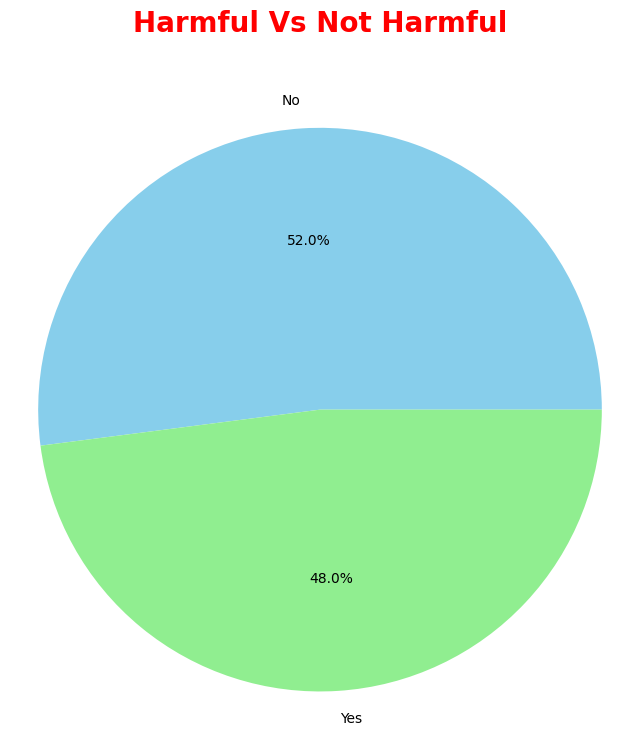

In [11]:
#percentage of harmful and not harmful bacteria in data
harmful_count = df["Harmful to Humans"].value_counts()

plt.figure(figsize = (8, 8))
plt.pie(harmful_count, labels = harmful_count.index, autopct = "%1.1f%%", colors = ["skyblue", "lightgreen"])
plt.title("Harmful Vs Not Harmful", fontsize = 20, color = "red", fontweight = "bold", y = 1.1)
plt.axis("equal")
plt.show()

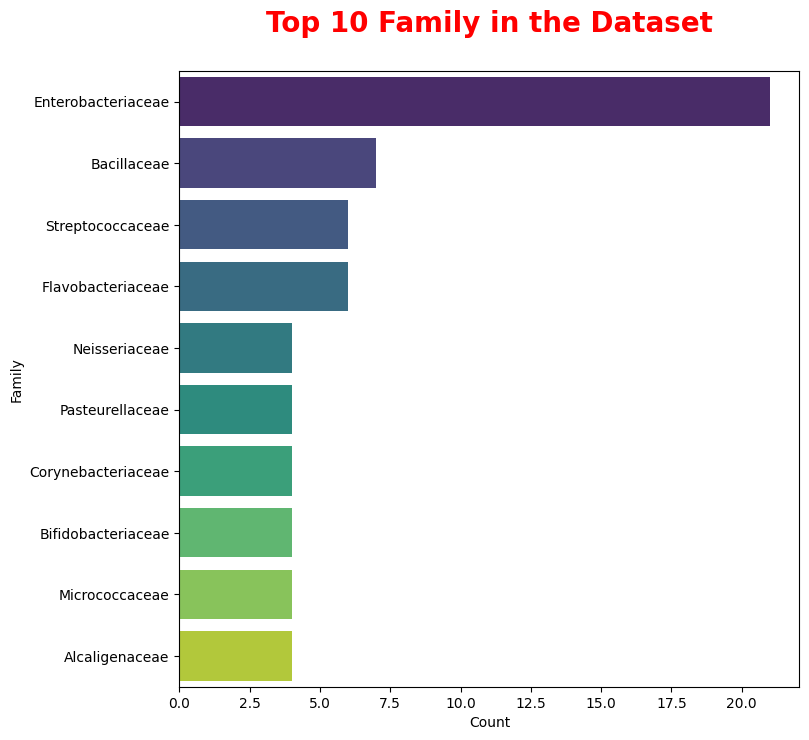

In [12]:
# top 10 families in data
family_counts = df["Family"].value_counts().head(10)

plt.figure(figsize = (8, 8))
sns.barplot(x = family_counts, y = family_counts.index, palette = "viridis")
plt.title("Top 10 Family in the Dataset", fontsize = 20, color = "red", fontweight = "bold", y = 1.05)
plt.xlabel("Count")
plt.ylabel("Family")
plt.show()

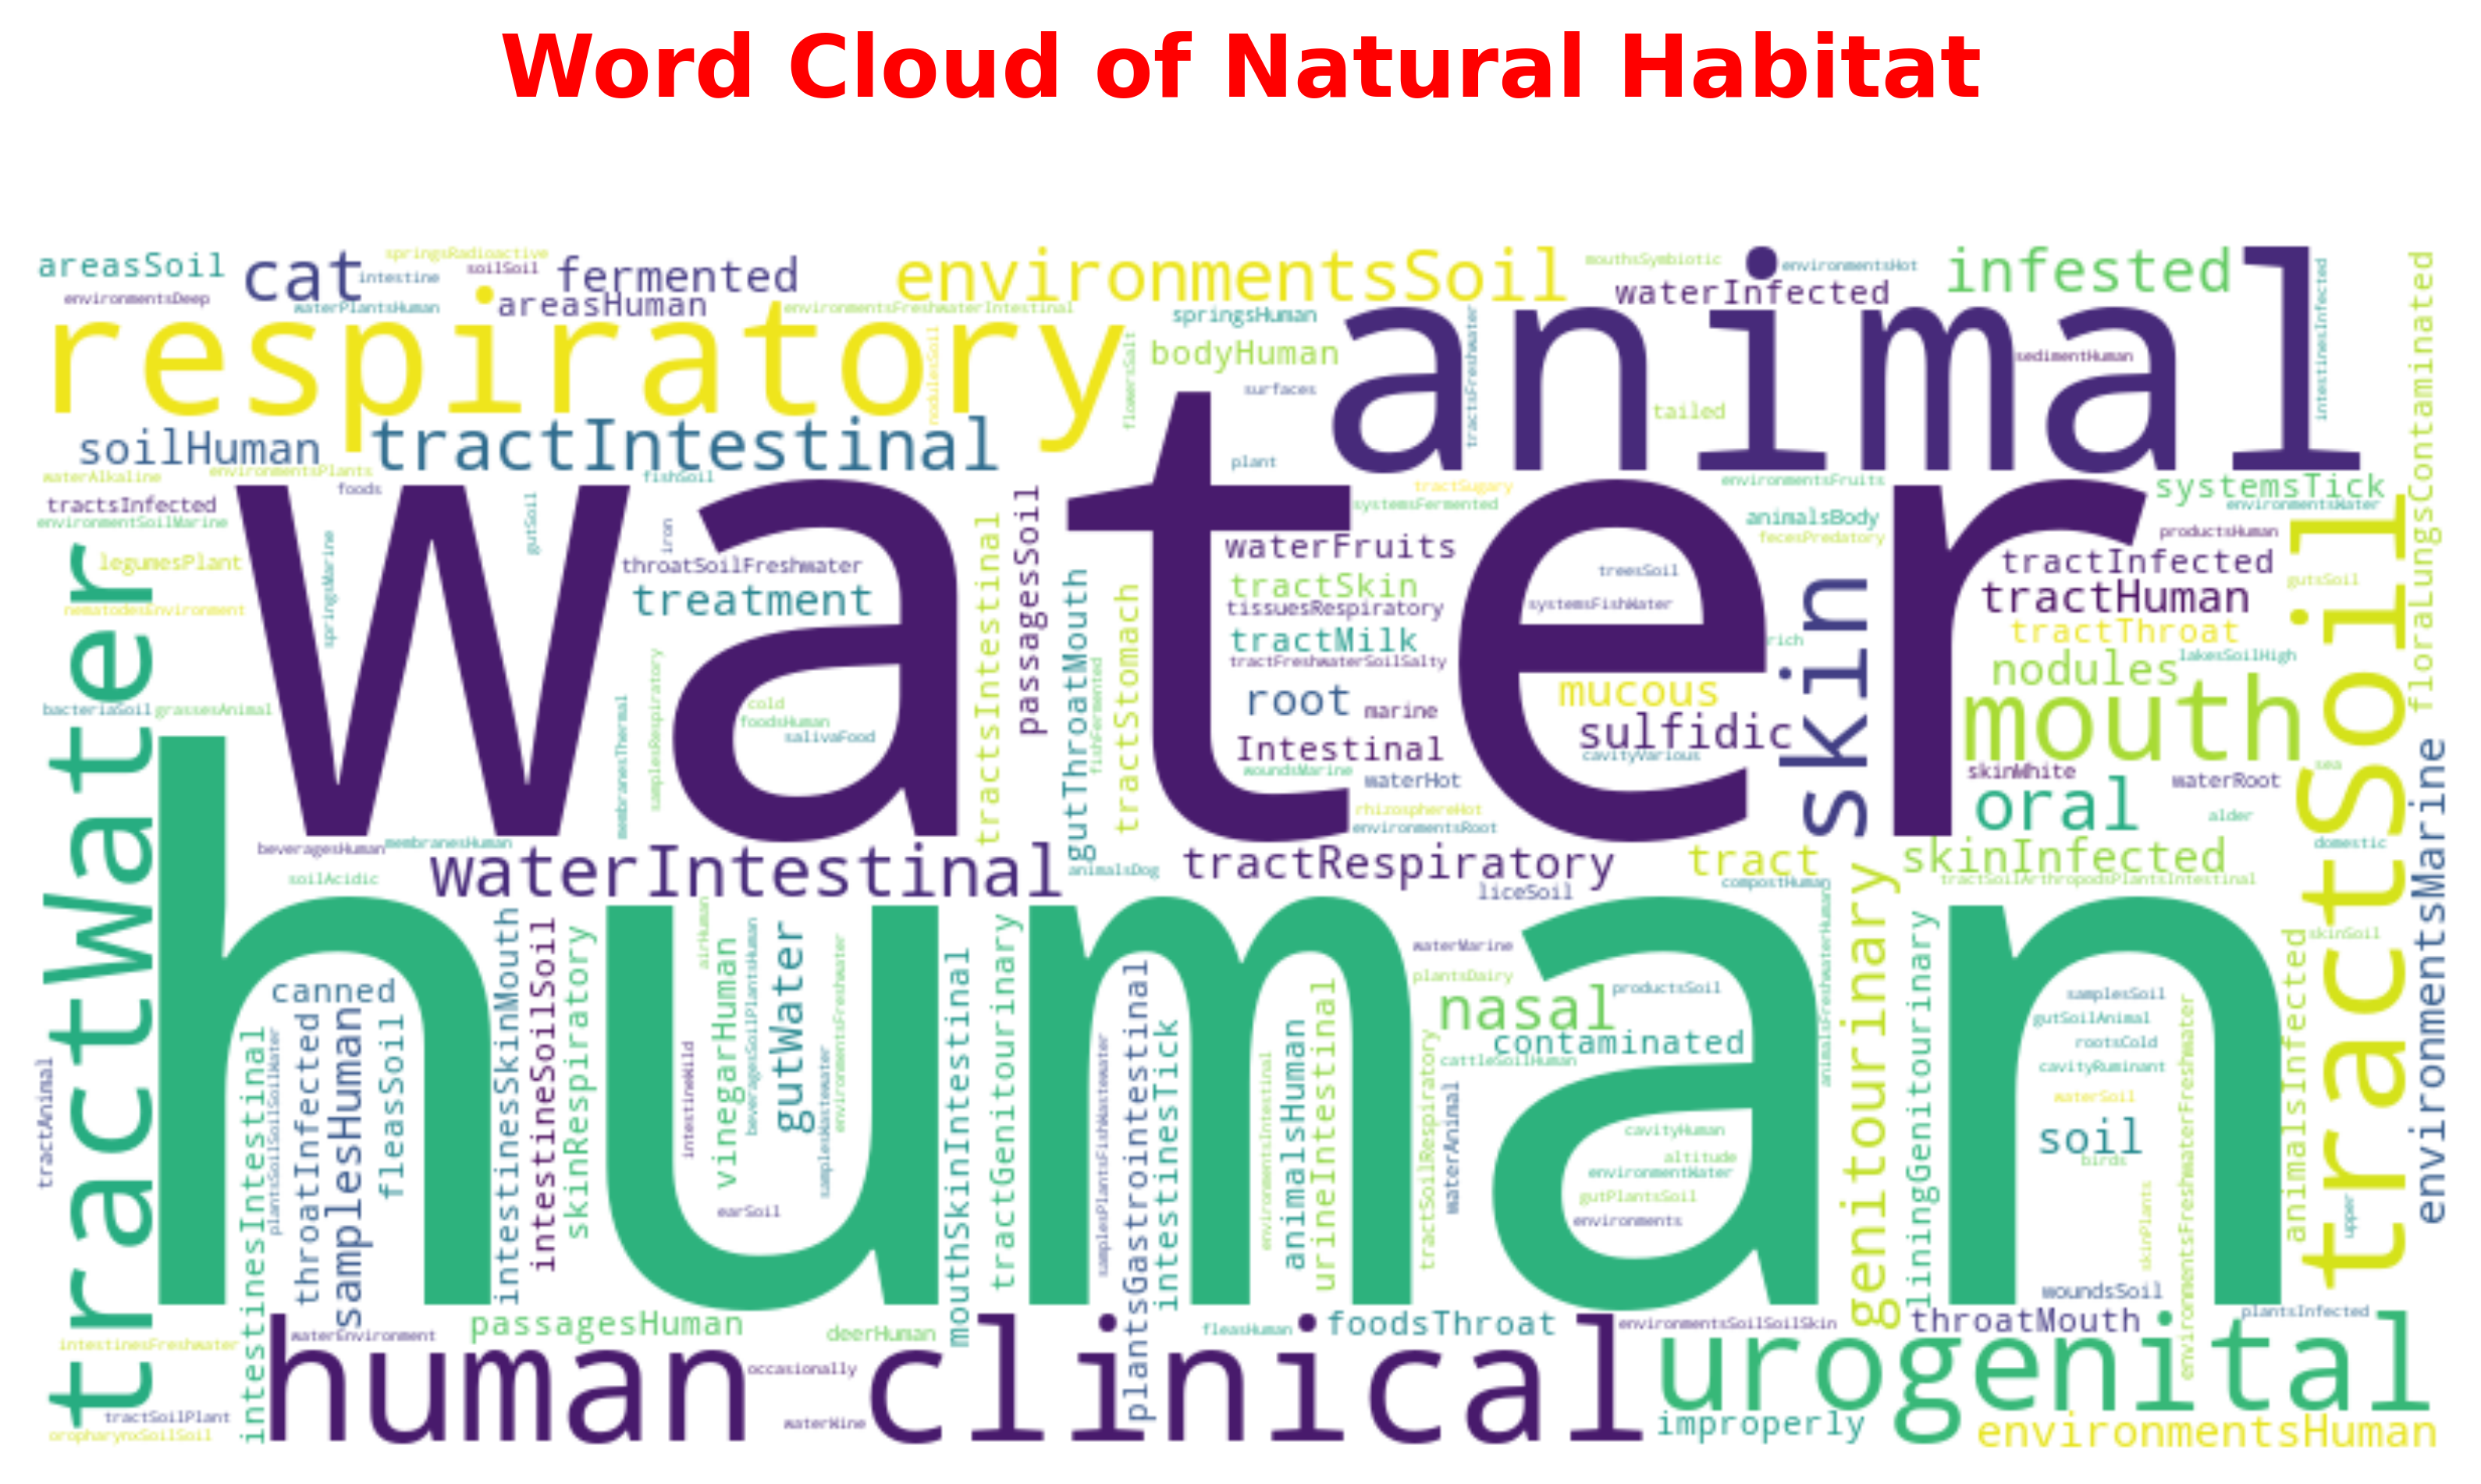

In [13]:
#Combine all Natural habitats into single string

habitat_text = "".join(df["Where Found"])

# Generate  a word cloud image

wordcloud = WordCloud(width = 800, height = 400, background_color = "white").generate(habitat_text)

# Plot the word cloud

plt.figure(figsize = (10, 6), dpi=400)
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.title("Word Cloud of Natural Habitat", fontsize = 20, color = "red", fontweight = "bold", y = 1.1)
plt.show()


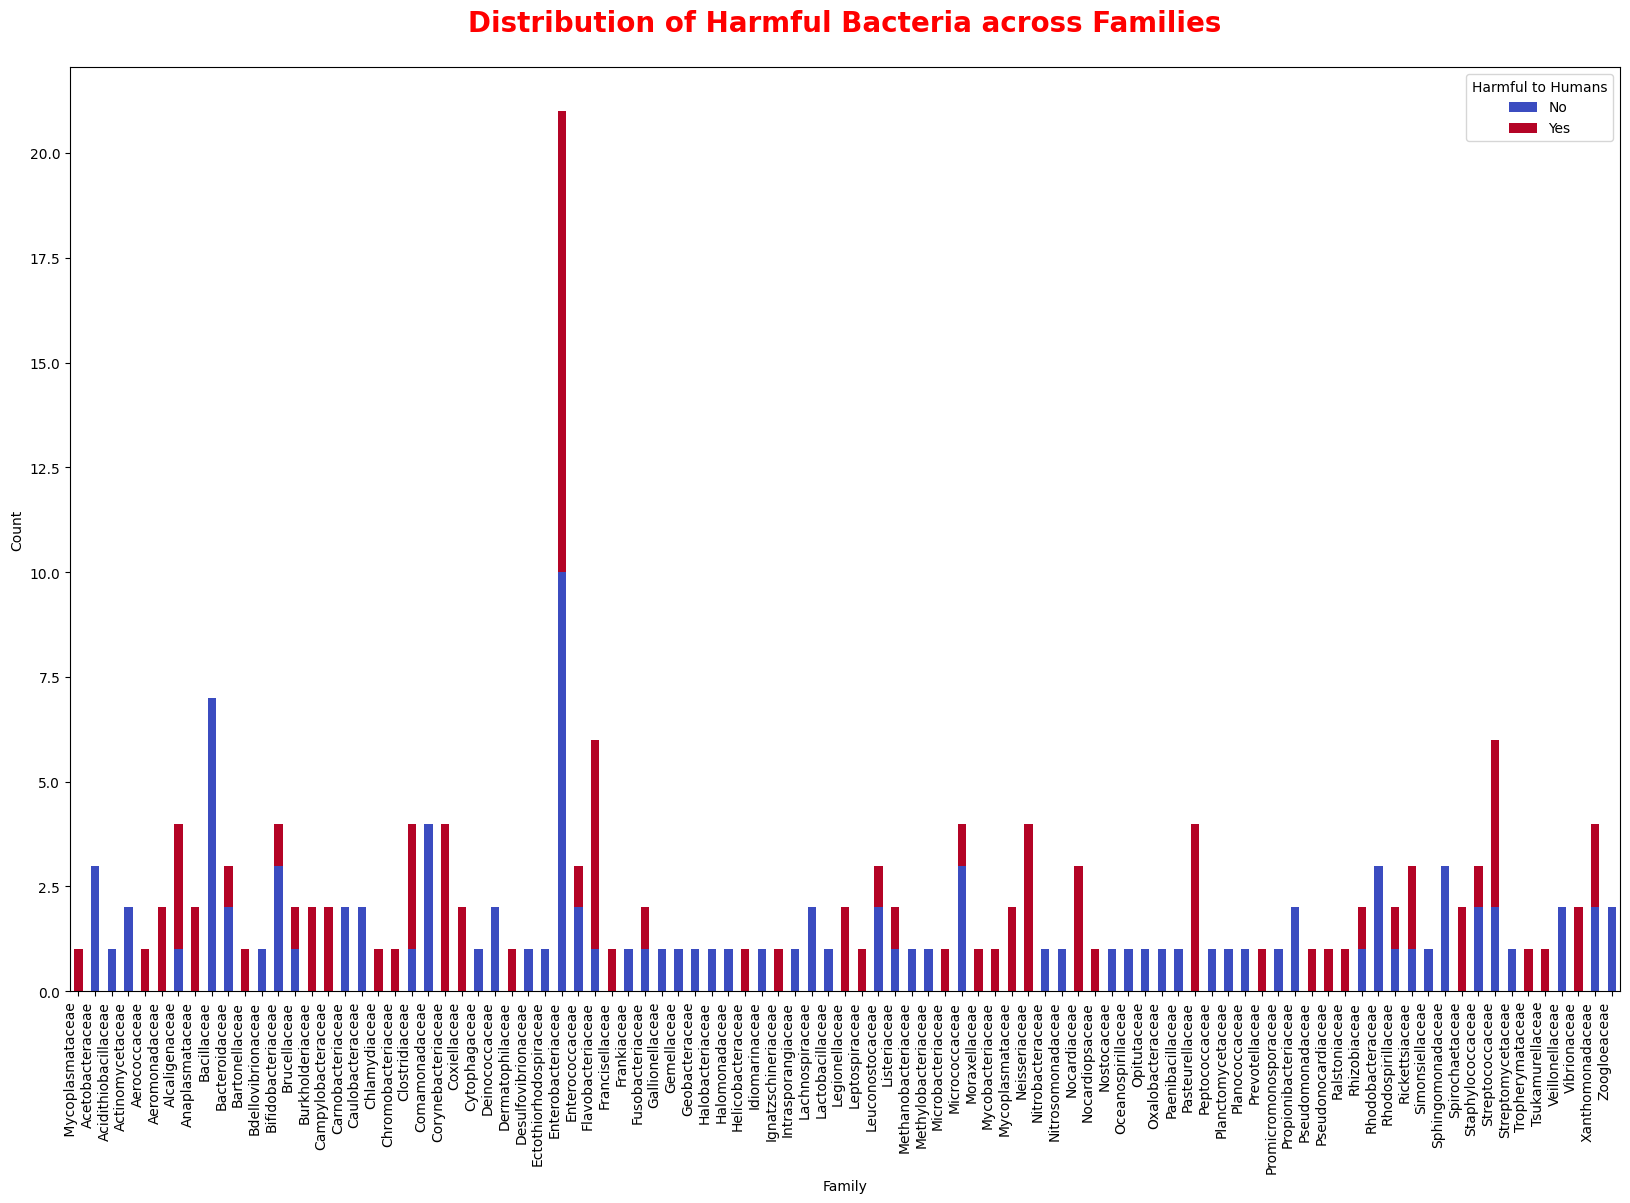

In [37]:
# Create a Stacked Bar Chart

stacked_data = df.groupby(["Family", "Harmful to Humans"]).size().unstack()
stacked_data.plot(kind = "bar", stacked = True, figsize = (20, 12), colormap = "coolwarm")
plt.title("Distribution of Harmful Bacteria across Families", fontsize = 20, color = "red", fontweight = "bold", y = 1.03)
plt.xlabel("Family")
plt.ylabel("Count")
plt.xticks(rotation = 90, ha = "right")
plt.legend(title = "Harmful to Humans", loc = "upper right")
plt.show()


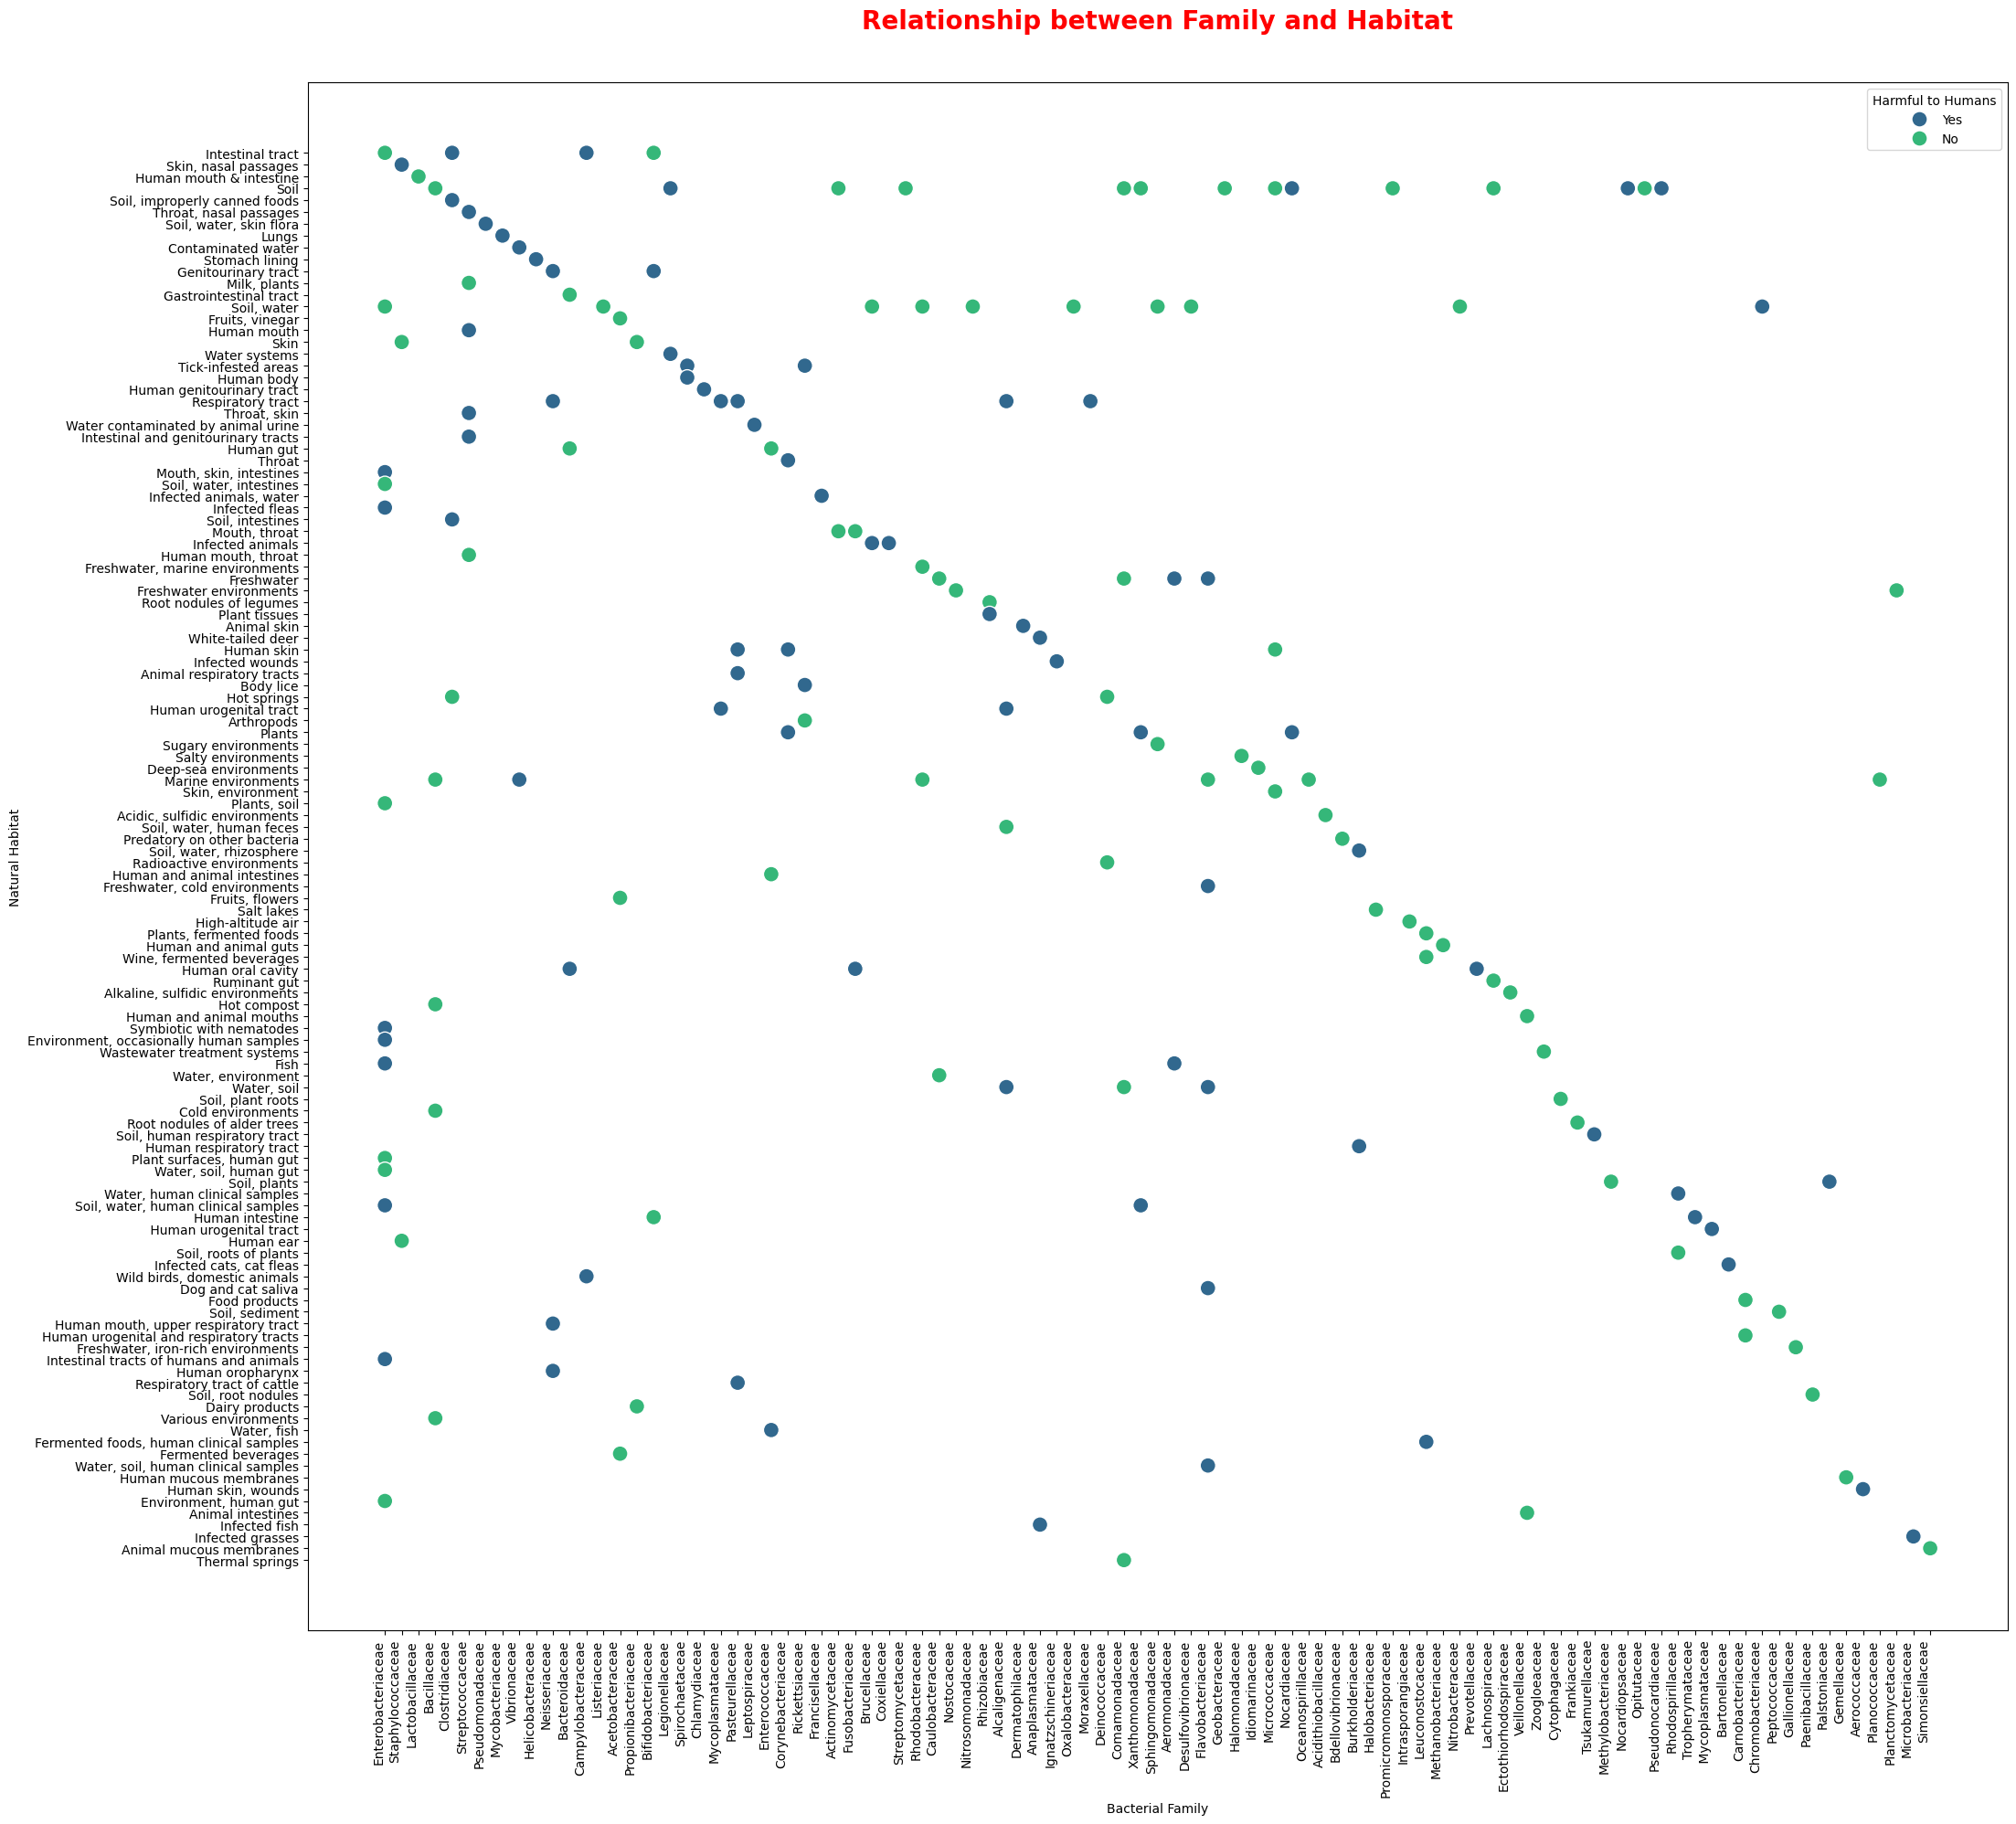

In [36]:
# Create a Scatter PLot

plt.figure(figsize = (24, 22))
sns.scatterplot(x = "Family", y = "Where Found", hue = "Harmful to Humans", data = df, palette = "viridis", s=150, alpha=1)
plt.title("Relationship between Family and Habitat", fontsize = 20, color = "red", fontweight = "bold", y = 1.03)
plt.xlabel("Bacterial Family")
plt.ylabel("Natural Habitat")
plt.xticks(rotation = 90, ha = "right")
plt.legend(title = "Harmful to Humans", loc = "upper right")
plt.show()


The count of full dangerous families of bacteria on human health in the dataset 33
Number of full dangerous families with more than one occurance in the dataset: 13


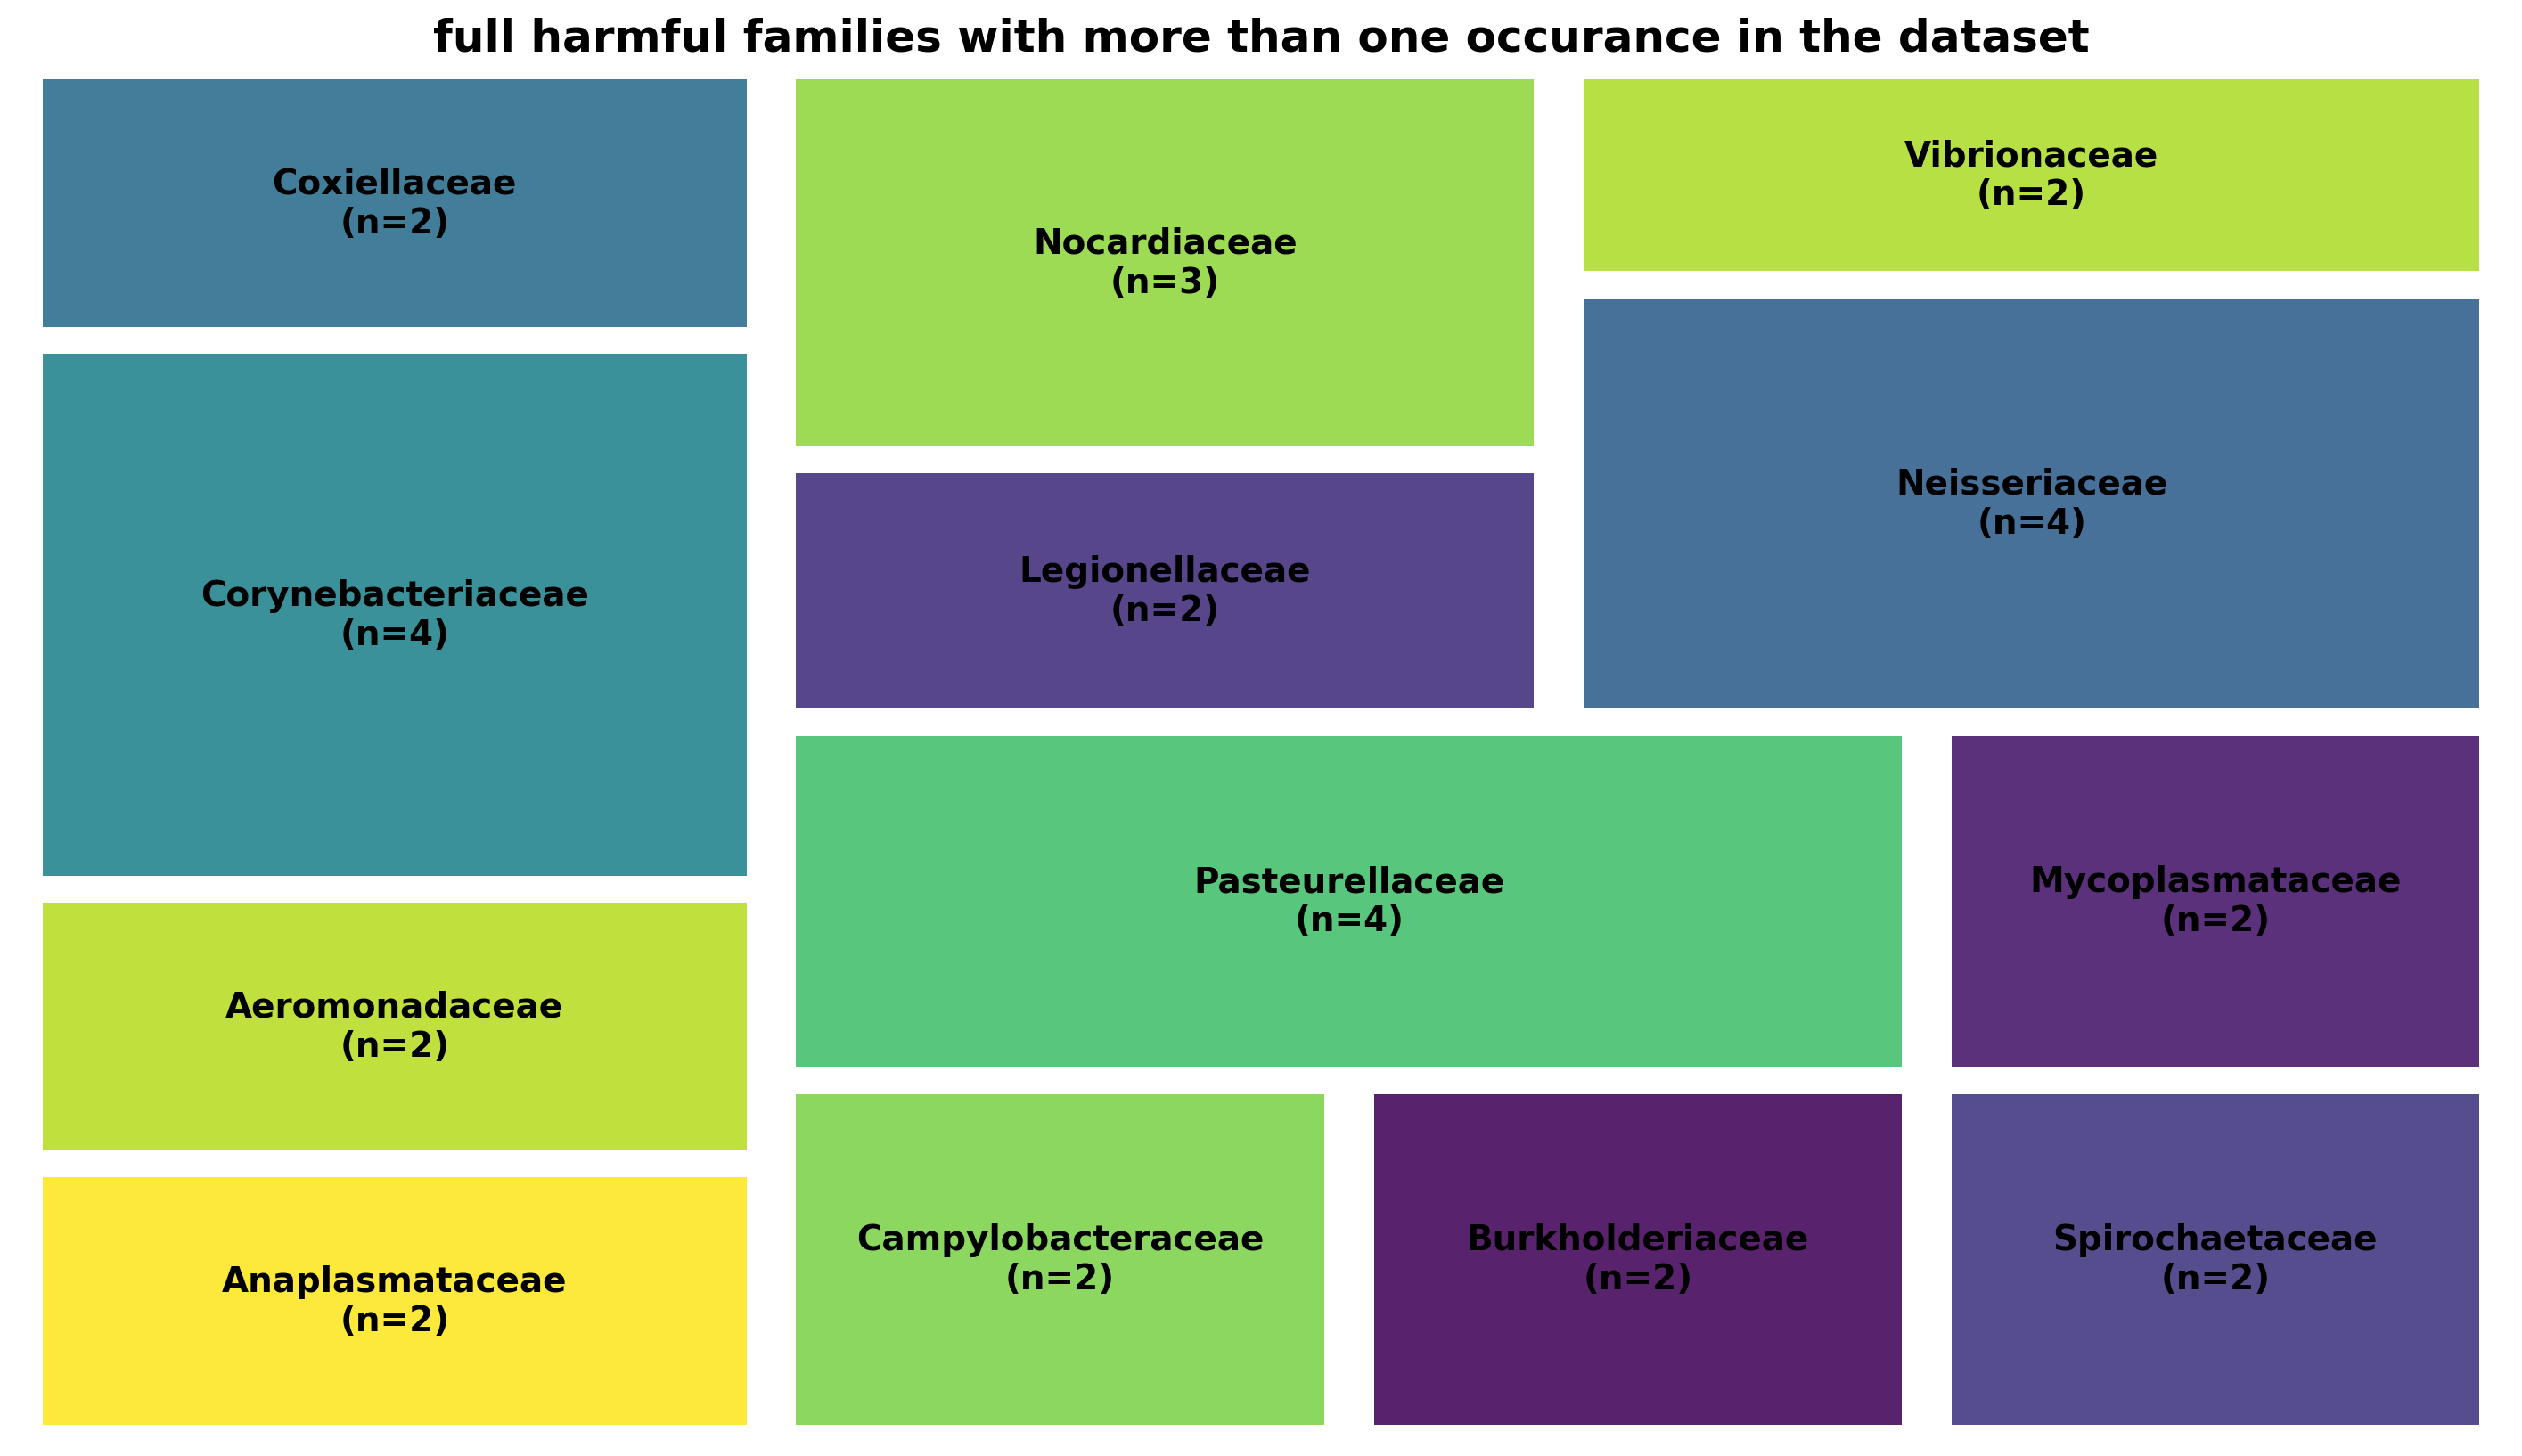

In [16]:
#the most dangerous families of bacteria on human health
family_stats = df.groupby('Family').agg(
    total=('Harmful to Humans', 'count'),
    harmful=('Harmful to Humans', lambda x: (x == 'Yes').sum())
)

family_stats['percentage'] = family_stats['harmful'] / family_stats['total']

family_stats_sorted = family_stats.sort_values(by='percentage', ascending=False)
family_stats_sorted = family_stats_sorted.reset_index()
family_full_dangerous = family_stats_sorted[family_stats_sorted['percentage'] == 1]
print('The count of full dangerous families of bacteria on human health in the dataset', family_full_dangerous.shape[0])

# select ones with more than one occurance in the dataset
family_full_dangerous = family_full_dangerous[family_full_dangerous['total'] > 1]
print("Number of full dangerous families with more than one occurance in the dataset:", family_full_dangerous.shape[0])

# Create labels
labels = family_full_dangerous.apply(
    lambda x: f"{x['Family']}\n(n={x['total']})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=family_full_dangerous["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 14, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "full harmful families with more than one occurance in the dataset",
    fontsize=18,
    fontweight="bold"
)

plt.show()

The count of families of bacteria with no danger on human health in the dataset 42
Number of full dangerous families with more than one occurance in the dataset: 13


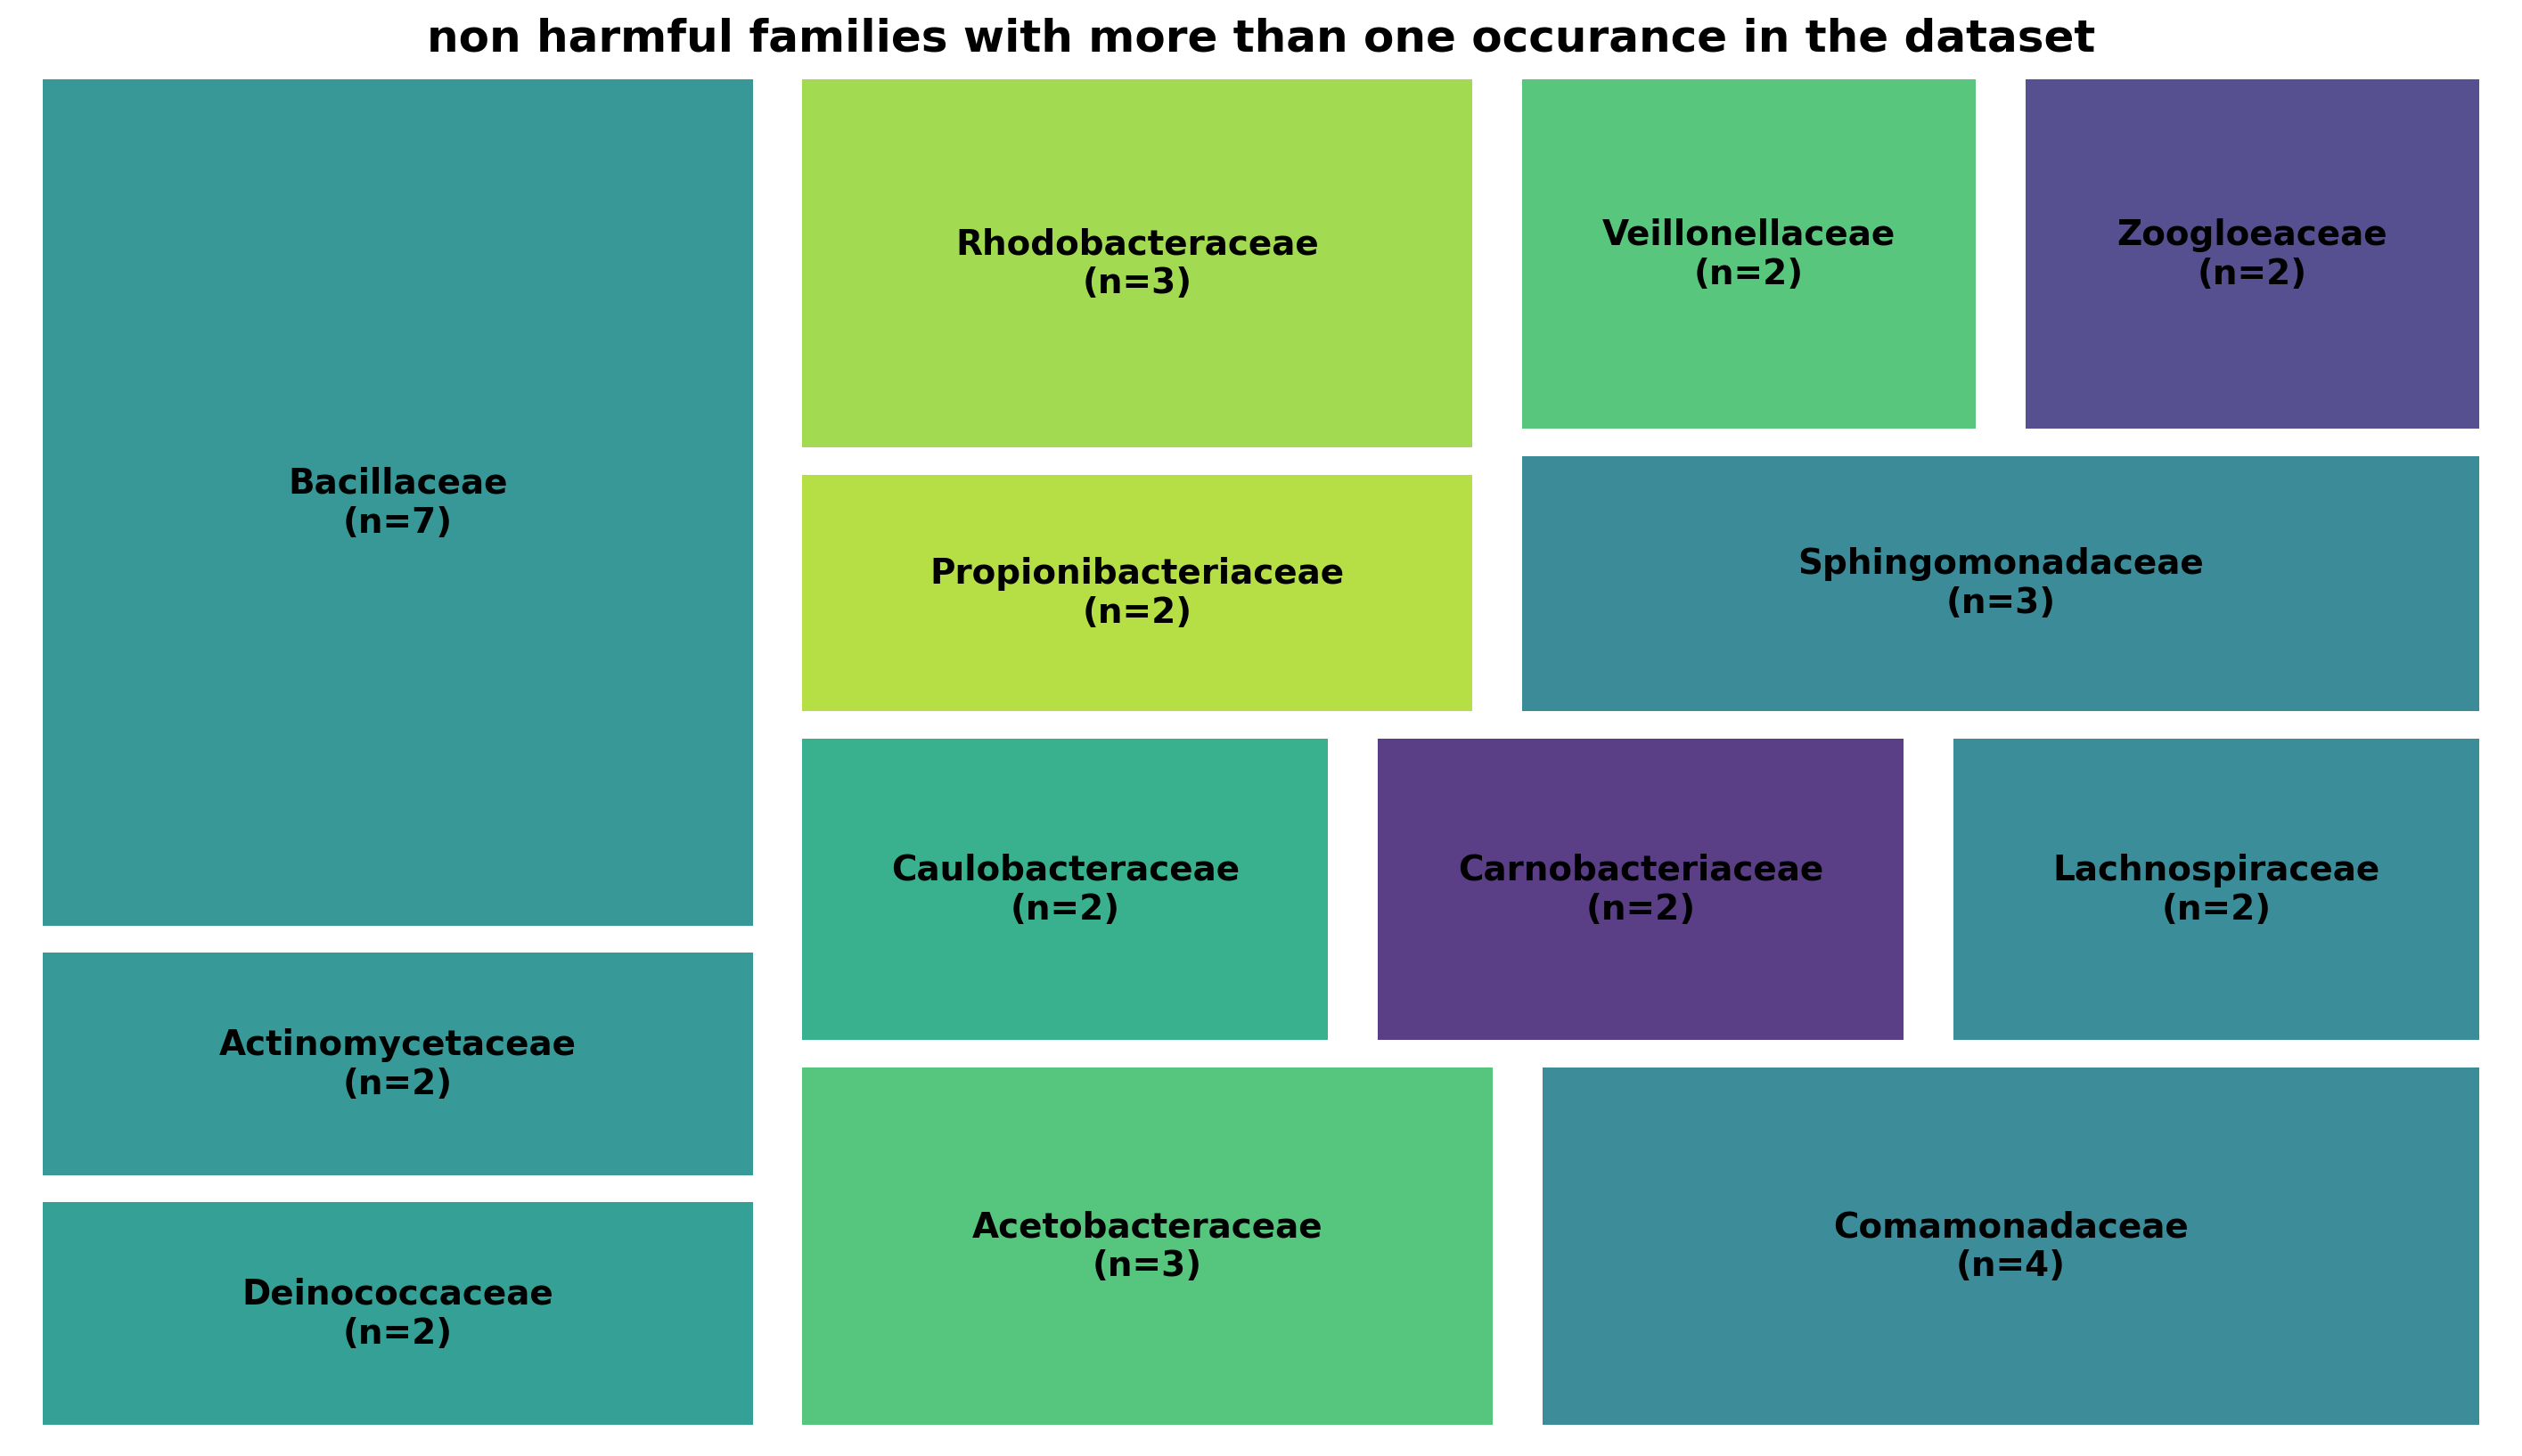

In [17]:
#families of bacteria with no danger on human health in dataset
family_no_danger = family_stats_sorted[family_stats_sorted['percentage'] == 0]
print('The count of families of bacteria with no danger on human health in the dataset', family_no_danger.shape[0])

# select ones with more than one occurance in the dataset
family_no_danger = family_no_danger[family_no_danger['total'] > 1]
print("Number of full dangerous families with more than one occurance in the dataset:", family_no_danger.shape[0])

# Create labels
labels = family_no_danger.apply(
    lambda x: f"{x['Family']}\n(n={x['total']})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=family_no_danger["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 14, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "non harmful families with more than one occurance in the dataset",
    fontsize=18,
    fontweight="bold"
)

plt.show()

Number of partially harmful bacterial families: 18


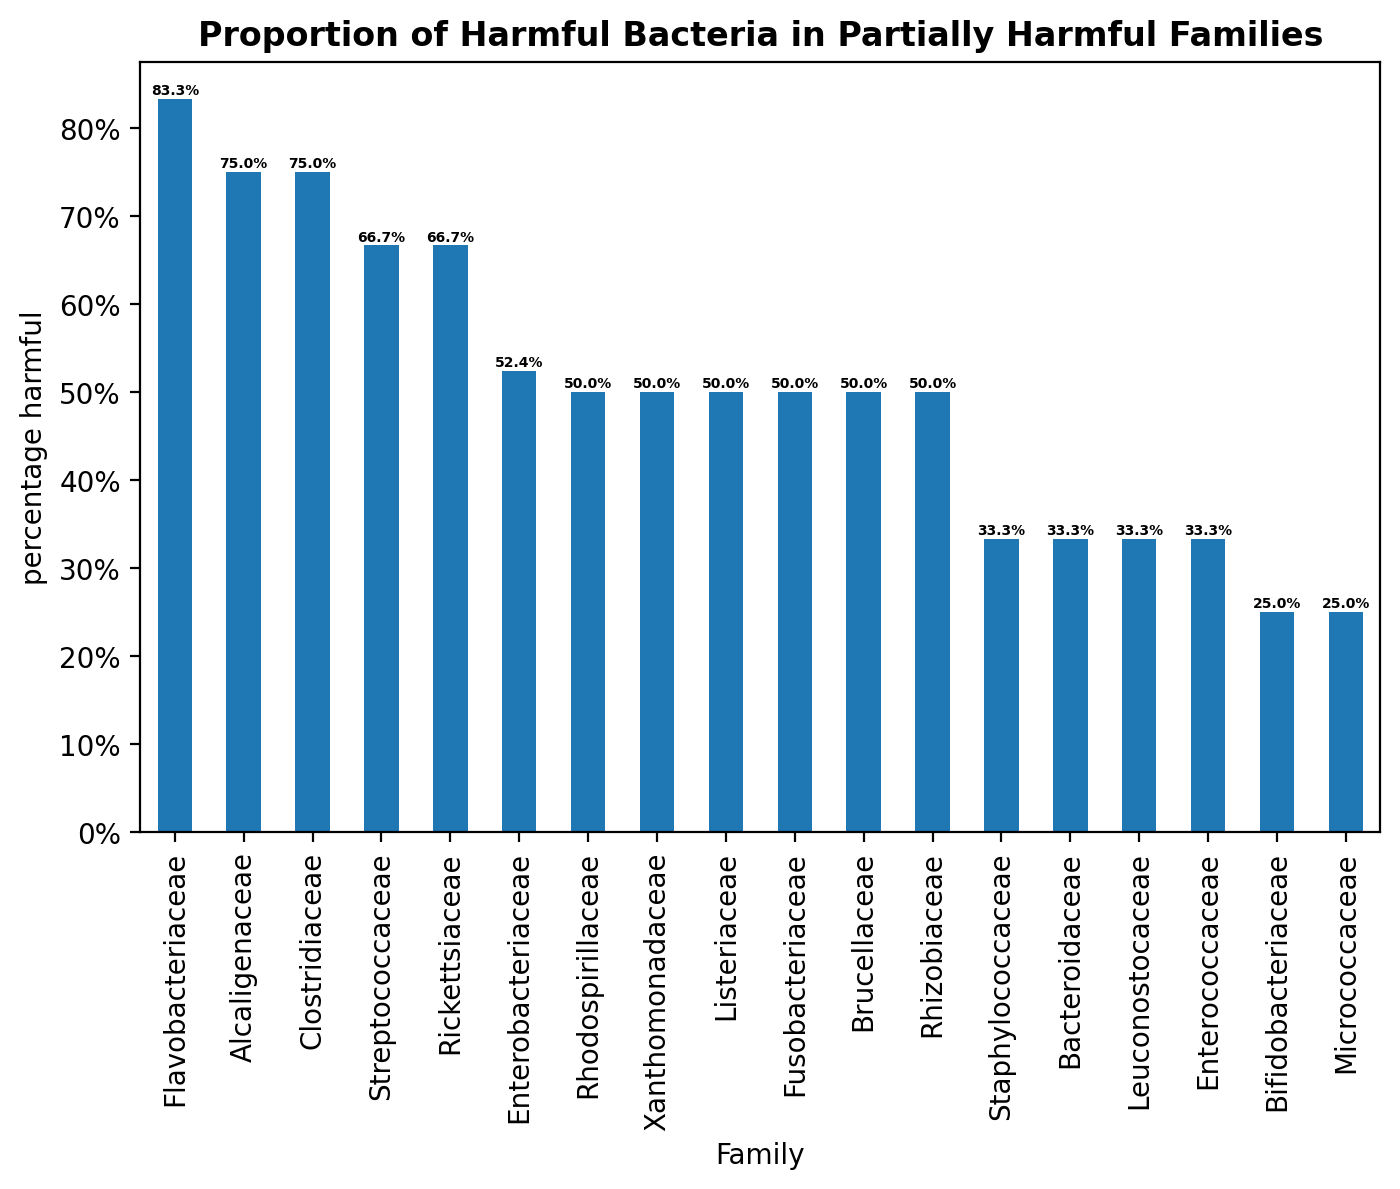

In [23]:
#families with partial danger on human health in the dataset
families_middle_danger = family_stats_sorted[(family_stats_sorted['percentage'] > 0) & (family_stats_sorted['percentage'] < 1)]
families_middle_danger = families_middle_danger.set_index('Family')
fig, ax=plt.subplots(figsize=(8, 5), dpi=200)
families_middle_danger['percentage'].plot.bar(ax=ax)
ax.set_ylabel('percentage harmful')
ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()]); 
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha='center',
        fontweight='bold',
        fontsize=5
    );
ax.set_title('Proportion of Harmful Bacteria in Partially Harmful Families', fontweight='bold')
print('Number of partially harmful bacterial families:', families_middle_danger.shape[0])

In [34]:
#the relationship between habitat and the highest proportion of harmful bacteria
habitat_stats = df.groupby(['Where Found']).agg(
    total=('Harmful to Humans', 'count'),
    harmful=('Harmful to Humans', lambda x: (x == 'Yes').sum())
)

habitat_stats['percentage'] = habitat_stats['harmful'] / habitat_stats['total']
habitat_stats.reset_index()

habitat_stats_sorted = habitat_stats.sort_values(by='percentage', ascending=False)
habitat_stats_sorted = habitat_stats_sorted.reset_index()
habitat_stats_sorted

,Where Found,total,harmful,percentage
0,Human urogenital tract,1,1,1.0
1,Animal respiratory tracts,1,1,1.0
2,Animal skin,1,1,1.0
3,Fish,2,2,1.0
4,Dog and cat saliva,1,1,1.0
...,...,...,...,...
115,Various environments,1,0,0.0
116,"Water, environment",1,0,0.0
117,Wastewater treatment systems,2,0,0.0
118,"Water, soil, human gut",1,0,0.0


Number of fully harmful habitats with more than one occurance in the dataset: 8


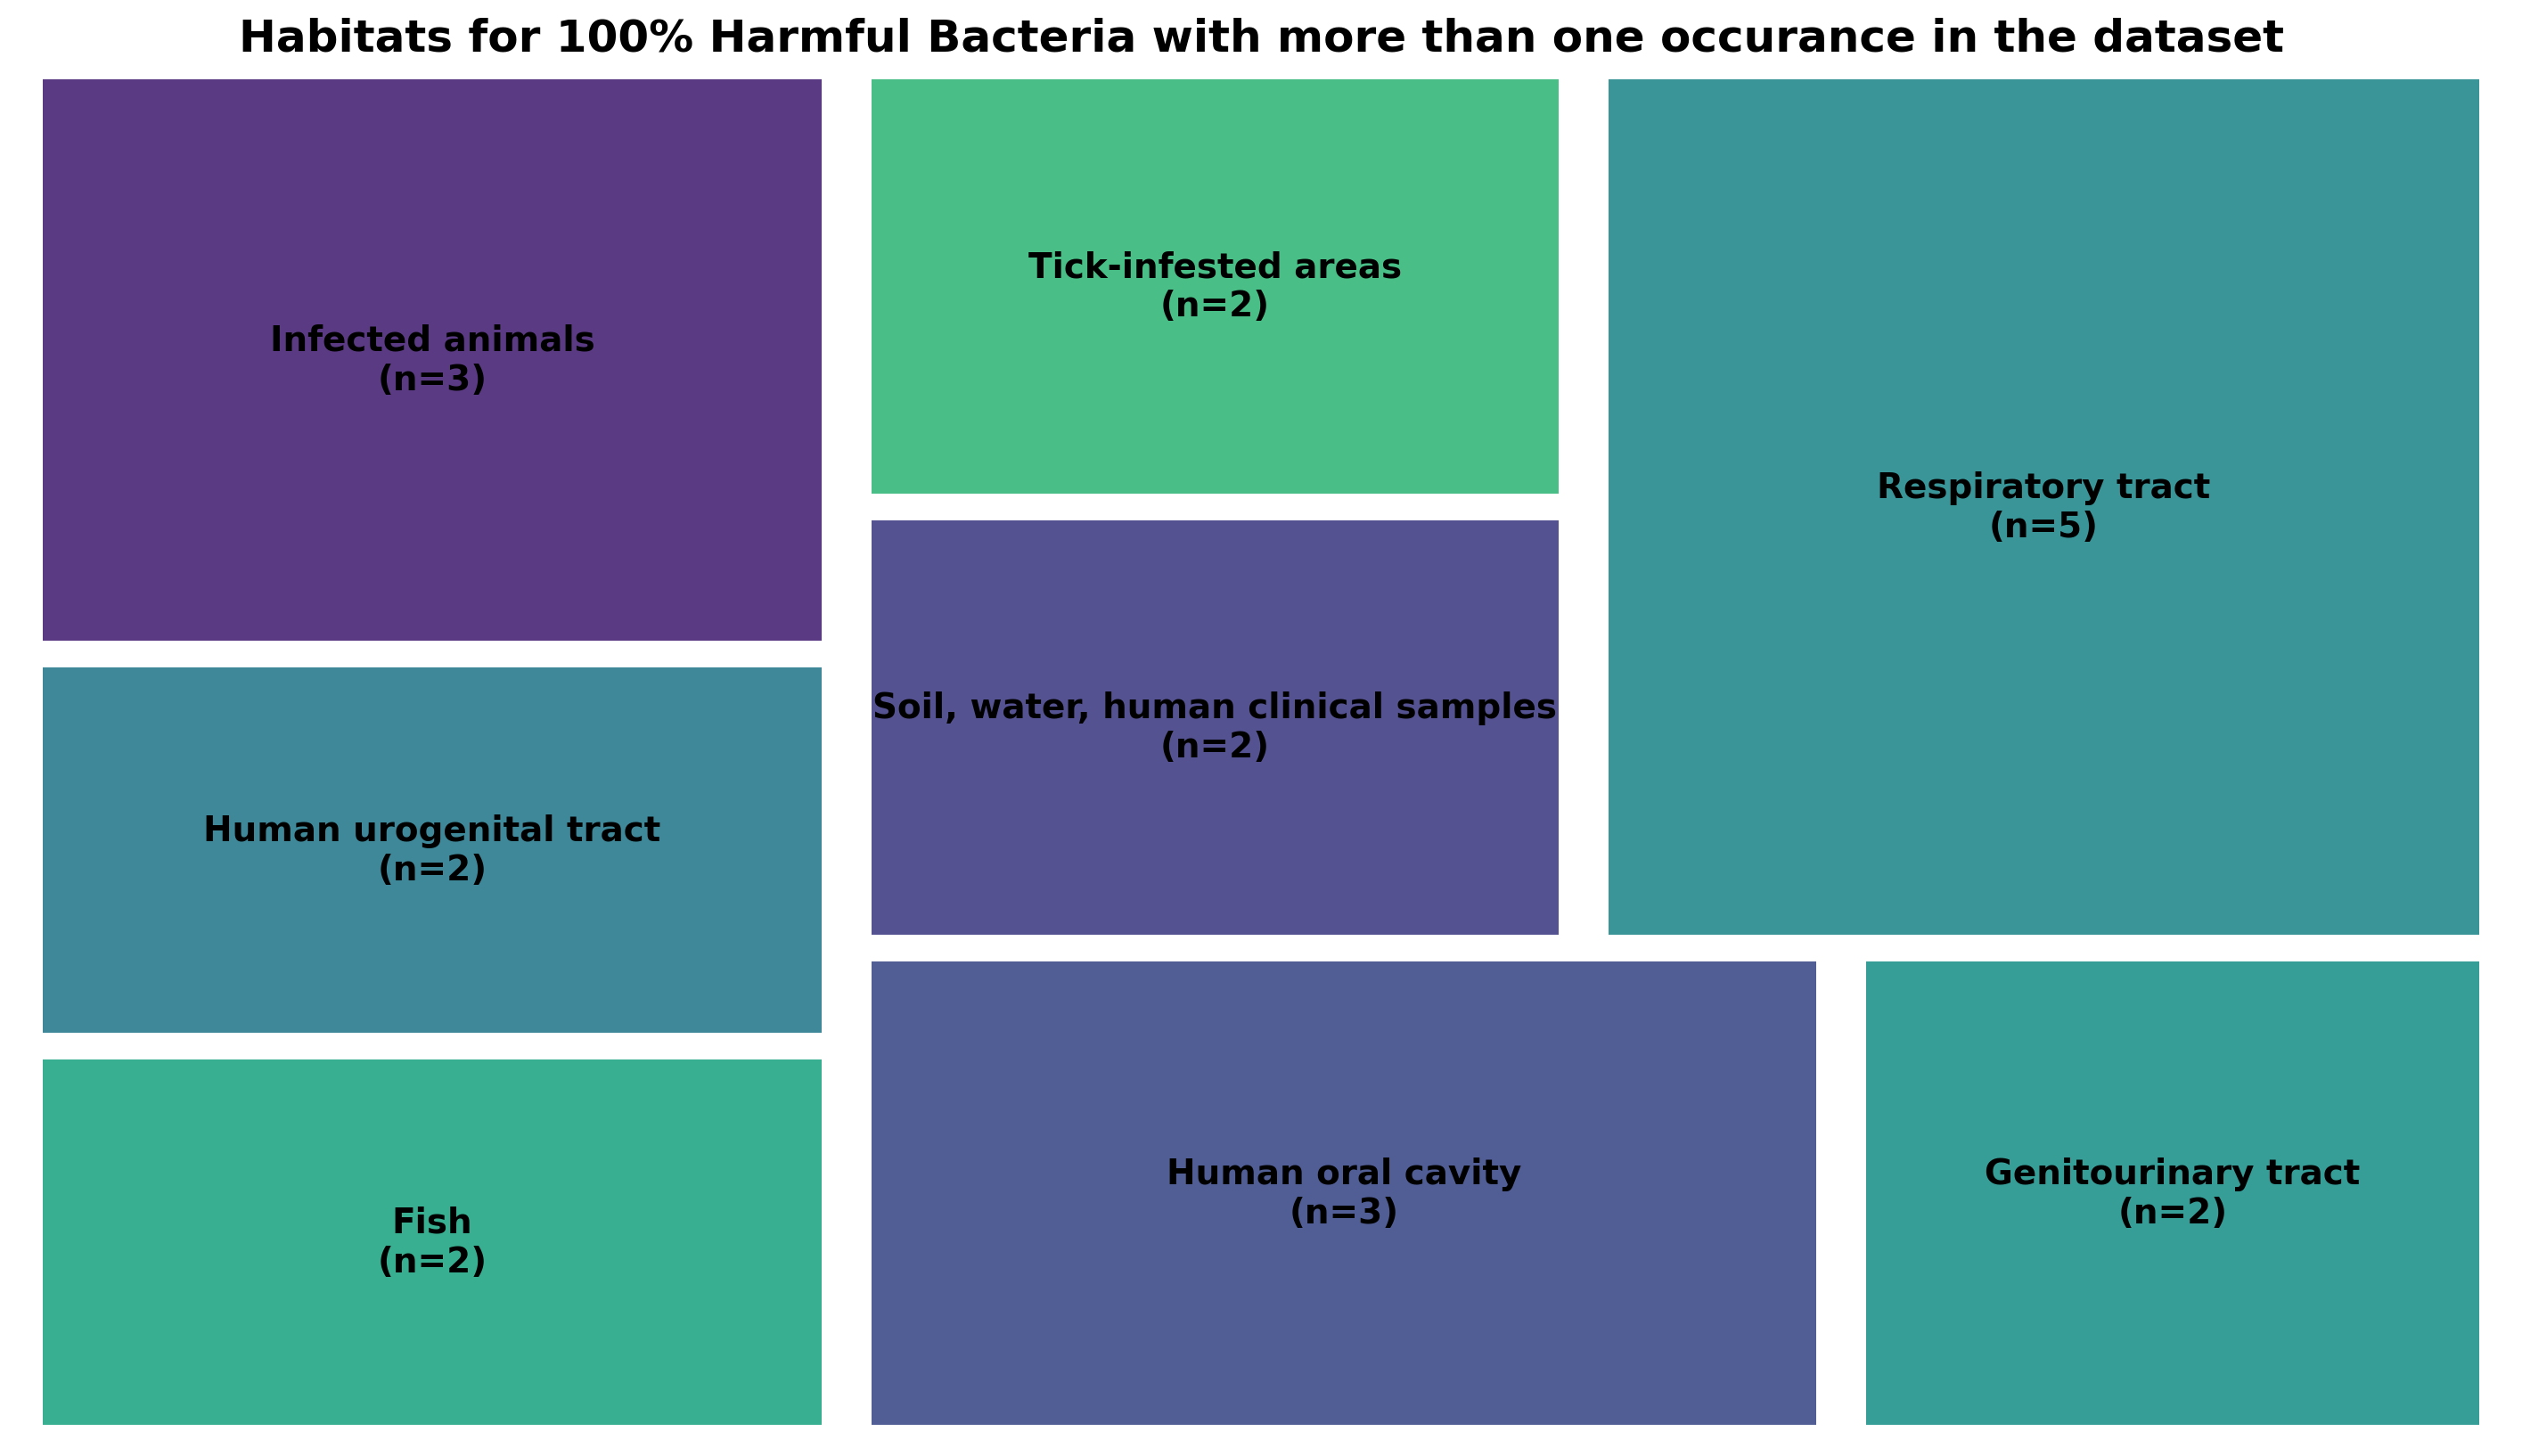

In [28]:
#habitats for exclusively harmful bacteria
# Filter 100% harmful habitats
habitat_stats_full_risk = habitat_stats_sorted[habitat_stats_sorted['percentage'] == 1]

# select ones with more than one occurance in the dataset
habitat_stats_full_risk = habitat_stats_full_risk[habitat_stats_full_risk['total'] > 1]
print("Number of fully harmful habitats with more than one occurance in the dataset:", habitat_stats_full_risk.shape[0])

# Create labels
labels = habitat_stats_full_risk.apply(
    lambda x: f"{x['Where Found']}\n(n={x['total']})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=habitat_stats_full_risk["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 14, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "Habitats for 100% Harmful Bacteria with more than one occurance in the dataset",
    fontsize=18,
    fontweight="bold"
)

plt.show()

Number of non harmful habitats with more than one occurance in the dataset: 6


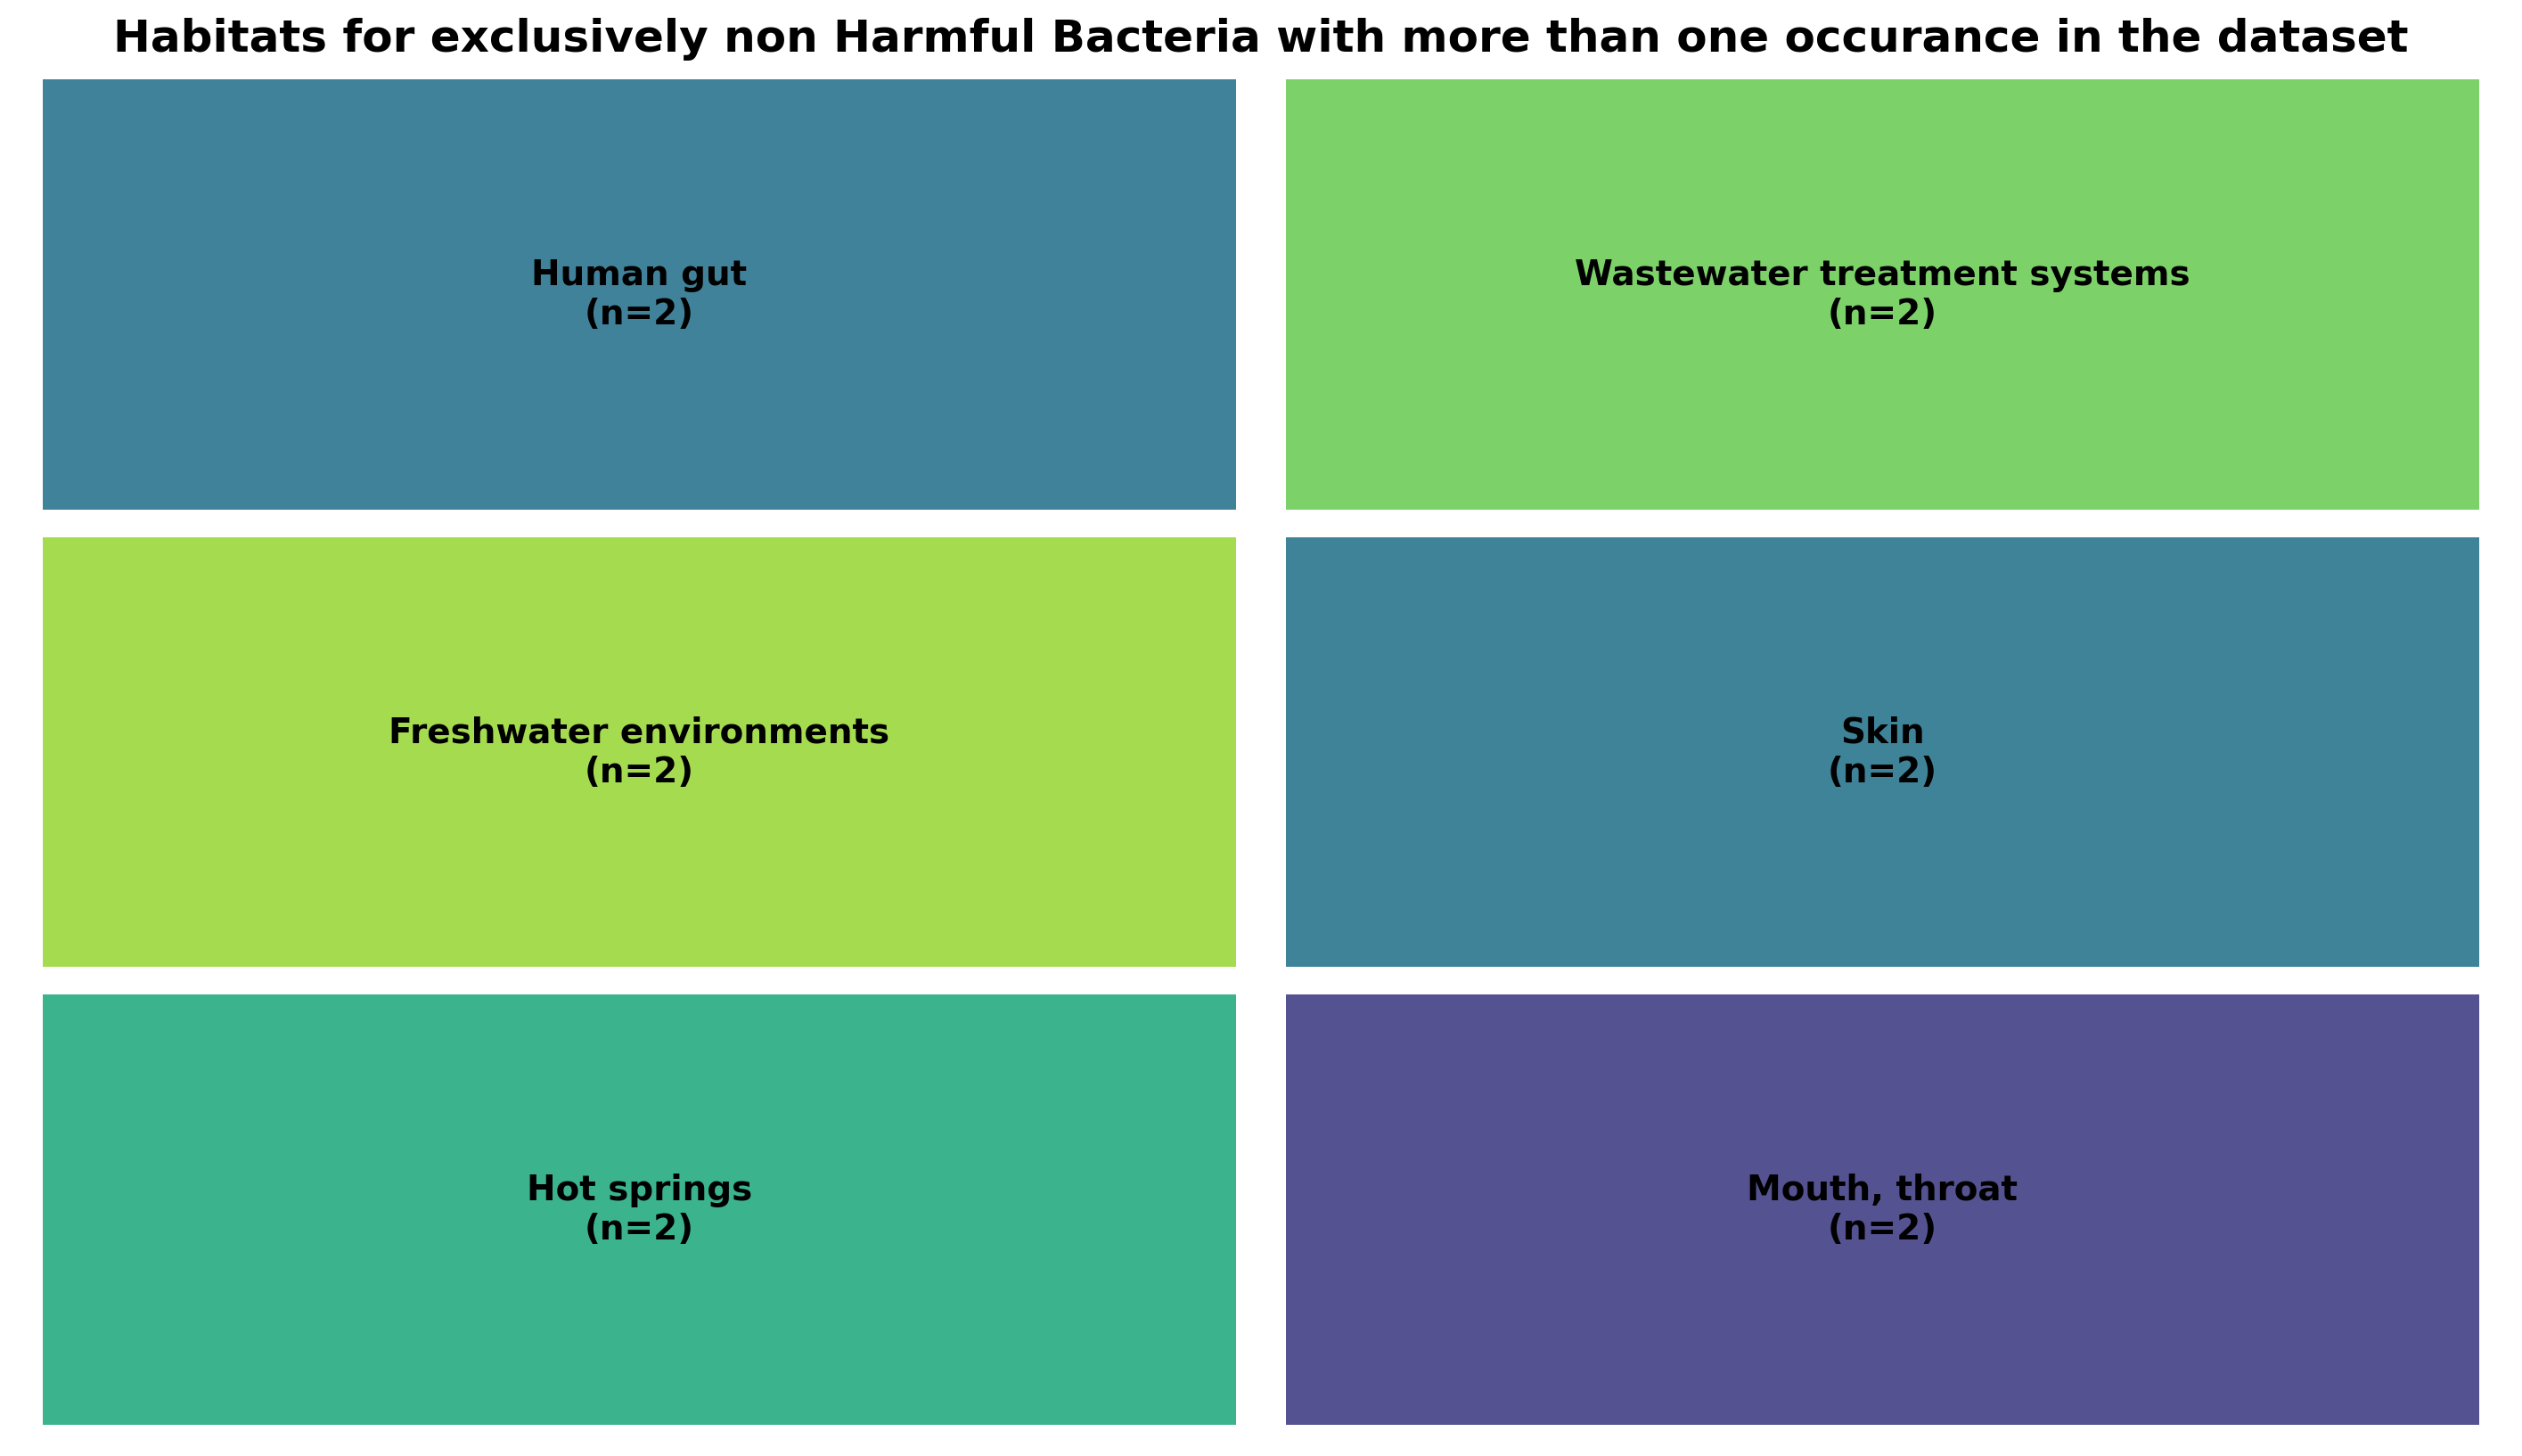

In [29]:
#habitats for exclusively non harmful bacteria on the human health with more than one occurance in the dataset
# Filter no harmful habitats
habitat_no_danger = habitat_stats_sorted[habitat_stats_sorted['percentage'] == 0]

# select ones with more than one occurance in the dataset
habitat_no_danger = habitat_no_danger[habitat_no_danger['total'] > 1]
print("Number of non harmful habitats with more than one occurance in the dataset:", habitat_no_danger.shape[0])

# Create labels
labels = habitat_no_danger.apply(
    lambda x: f"{x['Where Found']}\n(n={x['total']})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=habitat_no_danger["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 14, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "Habitats for exclusively non Harmful Bacteria with more than one occurance in the dataset",
    fontsize=18,
    fontweight="bold"
)

plt.show()

Number of non harmful habitats with more than one occurance in the dataset: 10


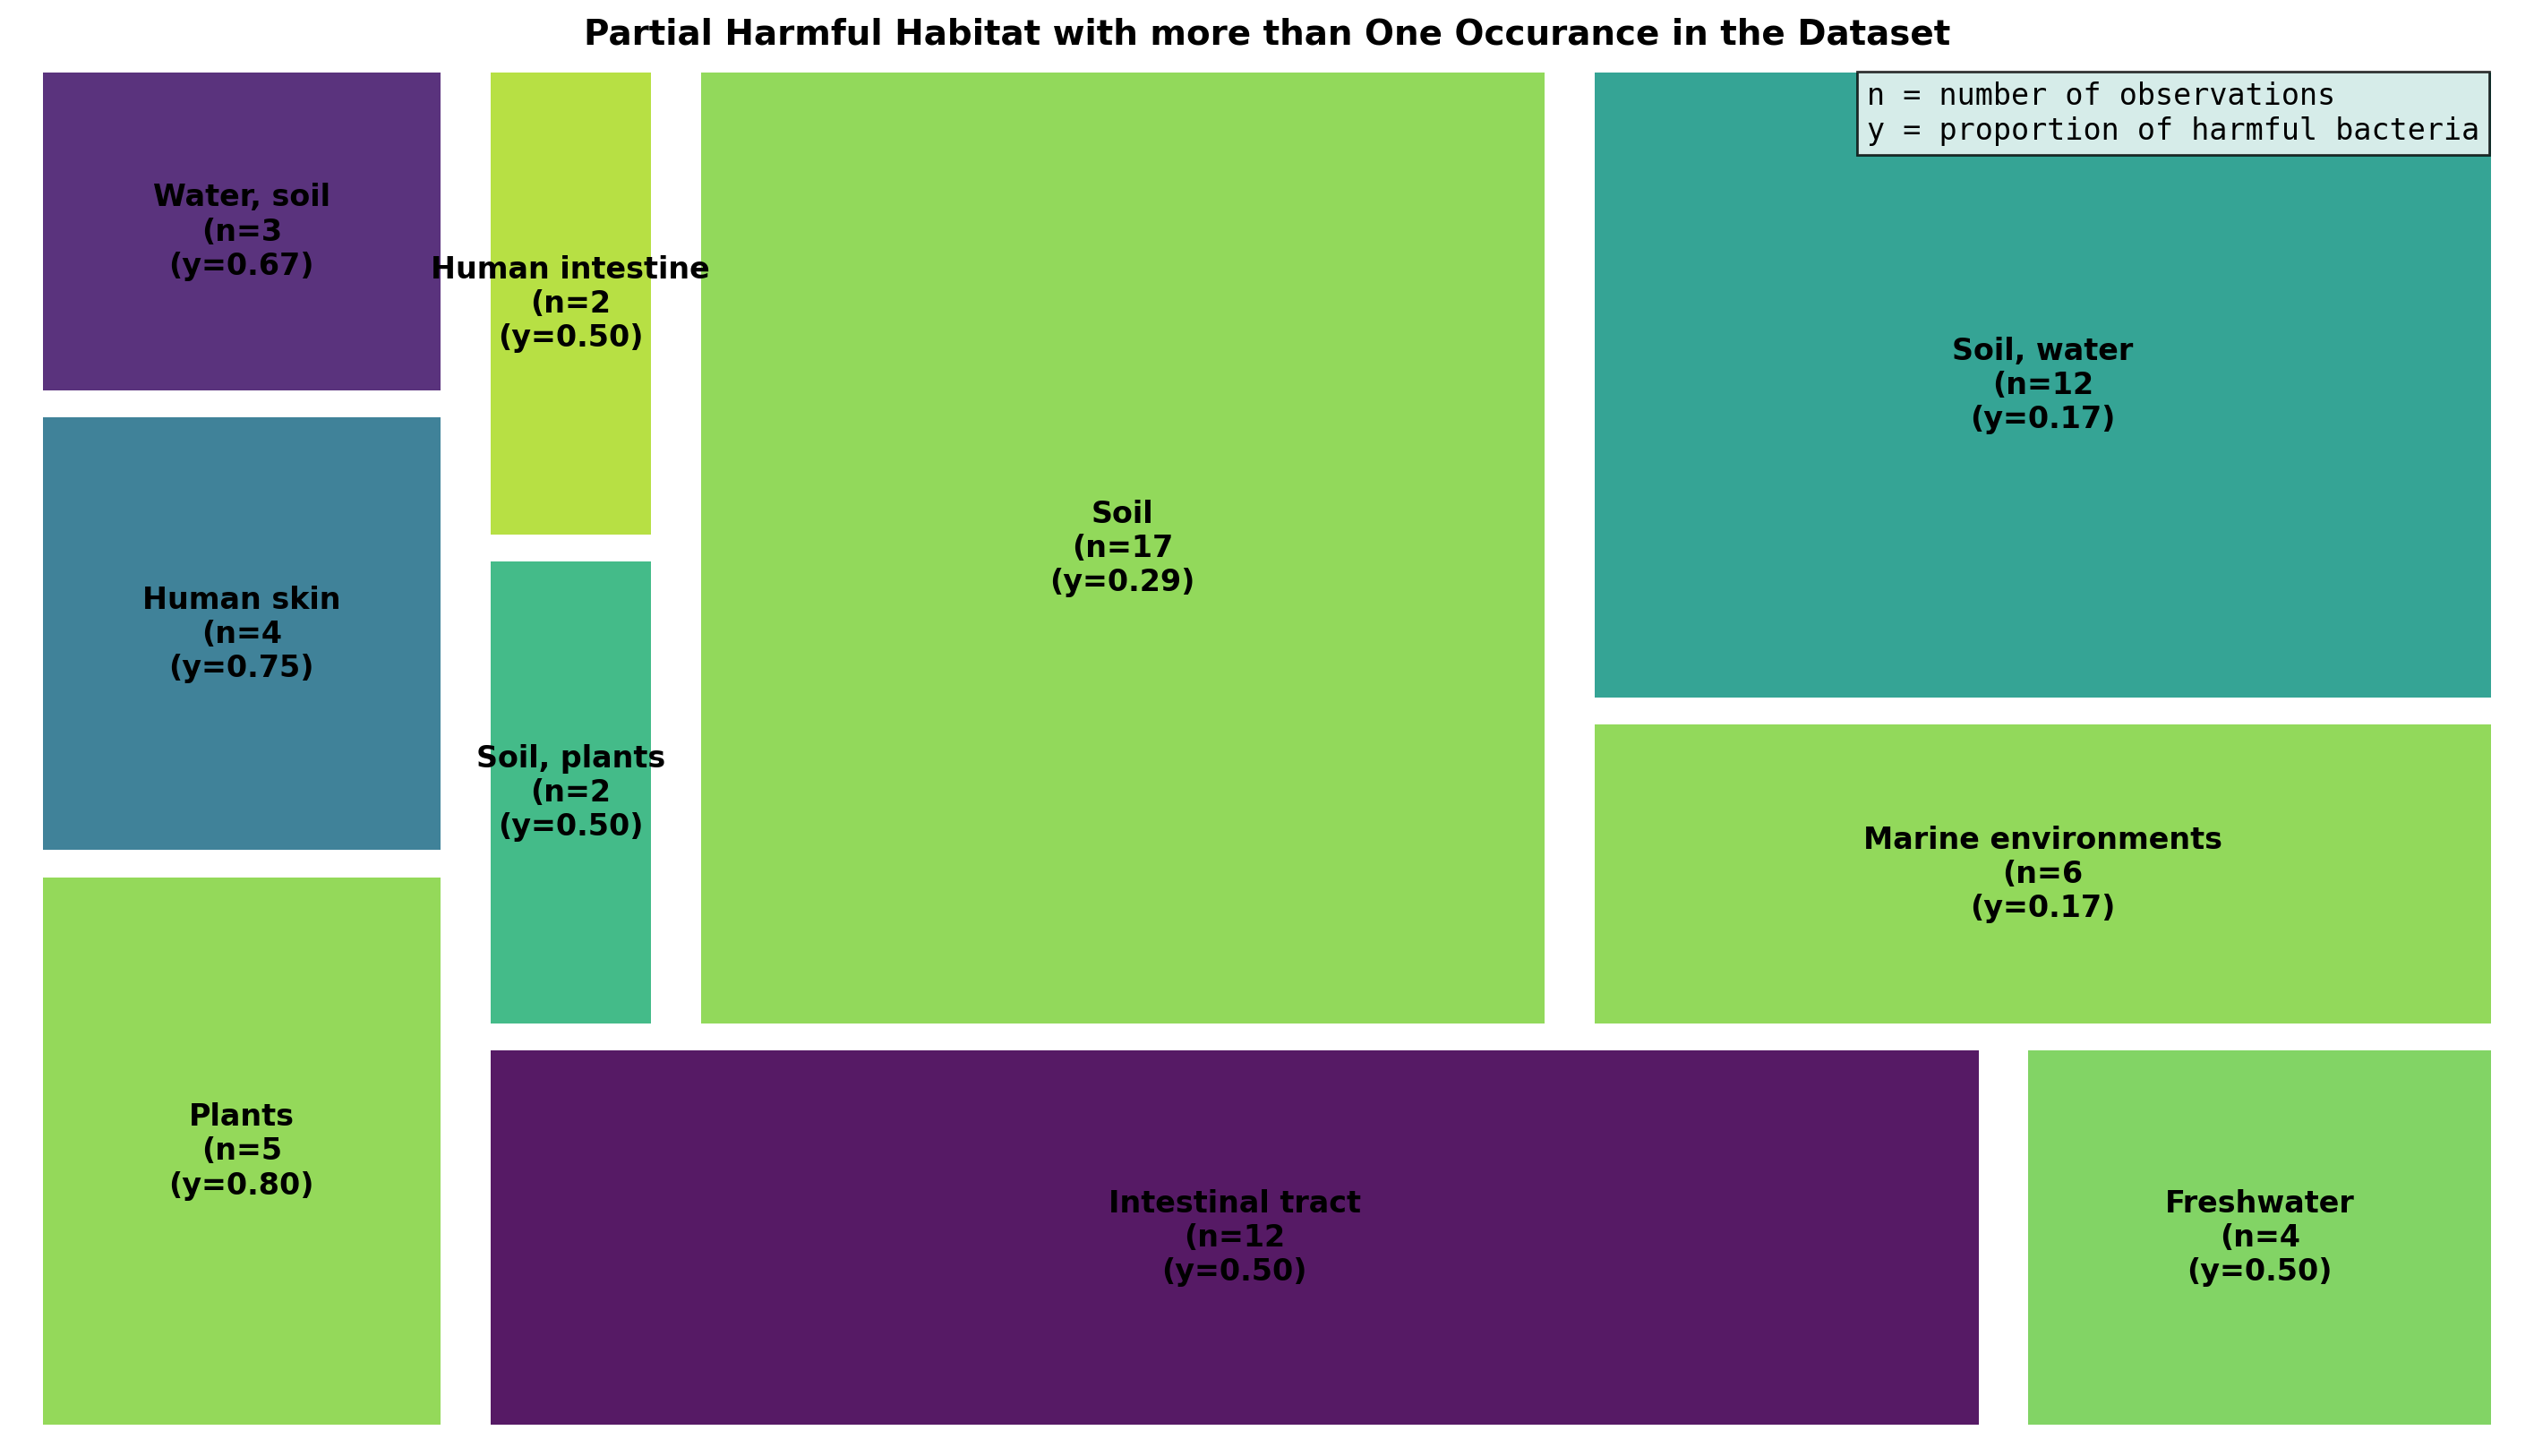

In [39]:
#habitats for partial harmful bacteria on the human health with more than one occurance in the dataset
# Filter partial harmful habitats
habitat_partial_danger = habitat_stats_sorted[(habitat_stats_sorted['percentage'] > 0) & (habitat_stats_sorted['percentage'] < 1)]

# select ones with more than one occurance in the dataset
habitat_partial_danger = habitat_partial_danger[habitat_partial_danger['total'] > 1]
print("Number of non harmful habitats with more than one occurance in the dataset:", habitat_partial_danger.shape[0])

# Create labels
labels = habitat_partial_danger.apply(
    lambda x: f"{x['Where Found']}\n(n={x['total']}\n(y={x['percentage']:.2f})",
    axis=1
)

# Plot
plt.figure(figsize=(18, 10), dpi=200)

squarify.plot(
    sizes=habitat_partial_danger["total"],
    label=labels,
    alpha=0.9,
    text_kwargs={"fontsize": 12, "fontweight": "bold"},
    pad=True
)

plt.axis("off")
plt.title(
    "Partial Harmful Habitat with more than One Occurance in the Dataset",
    fontsize=14,
    fontweight="bold"
)
plt.text(
    0.74, 0.984,
    "n = number of observations\n"
    "y = proportion of harmful bacteria",
    ha='left',
    va='top',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.8),
    transform=plt.gca().transAxes,
    family='monospace'
)
plt.show()

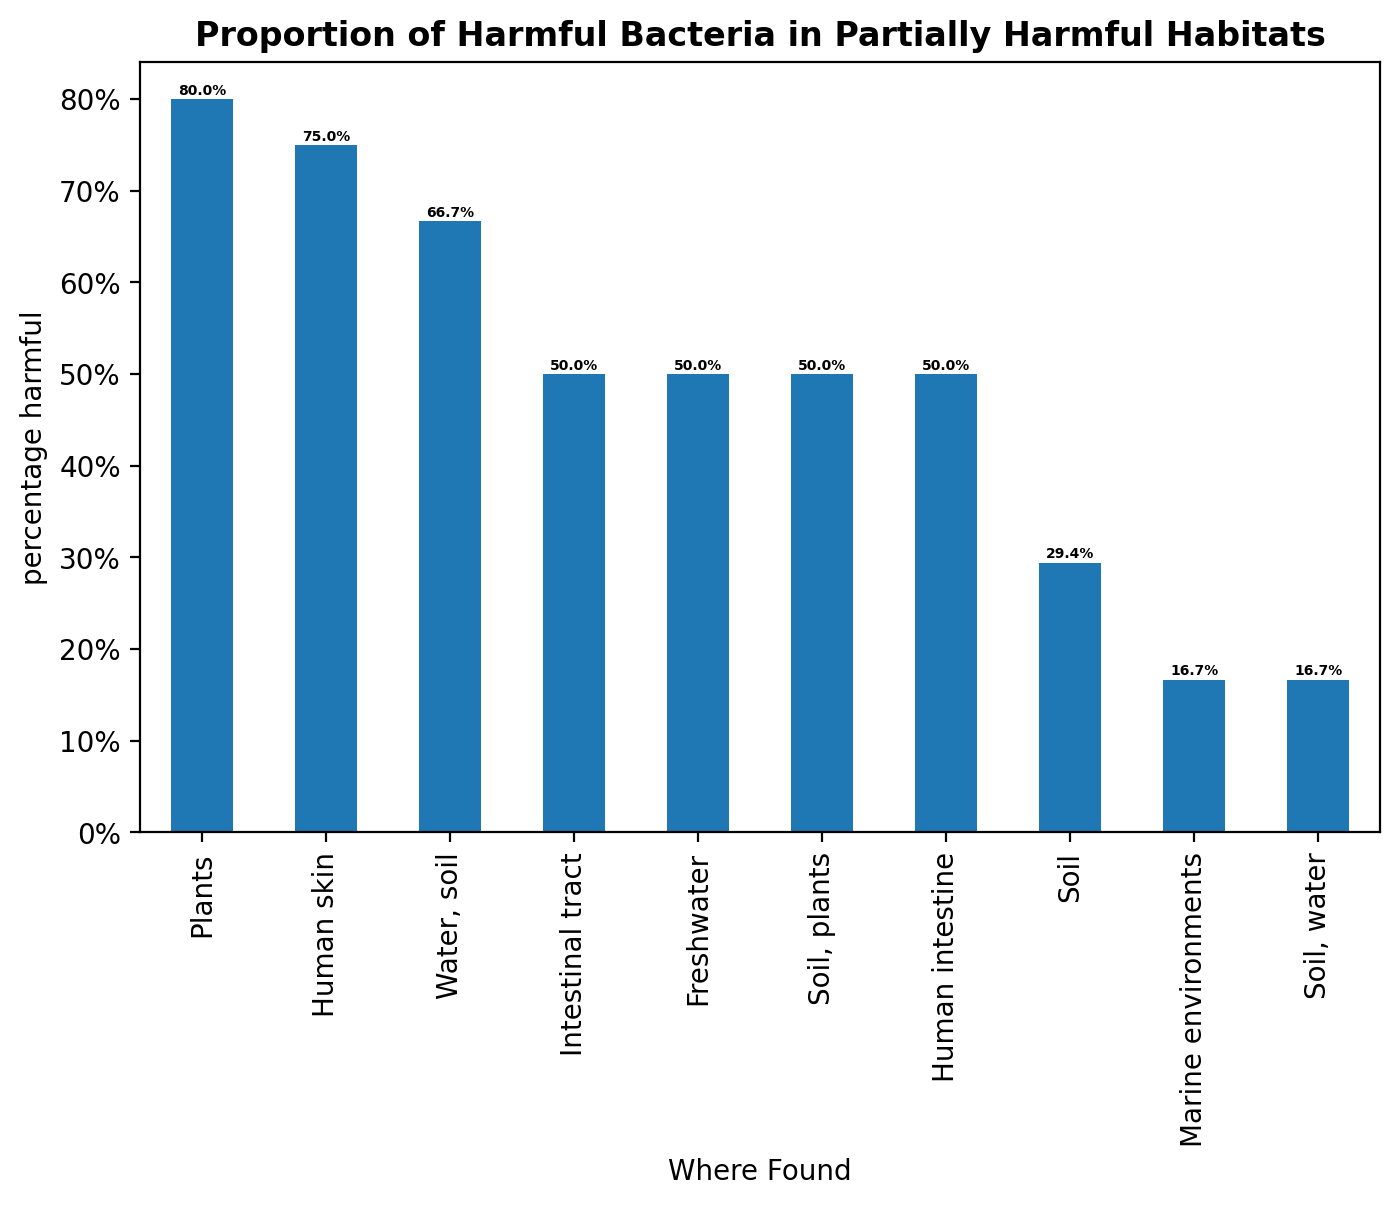

In [31]:
#habitats for partial harmful bacteria on the human health (visualization with bar plot)
habitat_partial_danger = habitat_partial_danger.set_index('Where Found')
fig, ax=plt.subplots(figsize=(8, 5), dpi=200)
habitat_partial_danger['percentage'].plot.bar(ax=ax)
ax.set_ylabel('percentage harmful')
ax.set_yticklabels(['{:.0f}%'.format(x*100) for x in ax.get_yticks()]); 
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.1%}",
        ha='center',
        fontweight='bold',
        fontsize=5
    );
ax.set_title('Proportion of Harmful Bacteria in Partially Harmful Habitats', fontweight='bold')
plt.show()

In [33]:
# Prepare the data for treemap

treemap_data = df.groupby(["Family", "Where Found"]).size().reset_index(name = "Count")
treemap_data = treemap_data[treemap_data['Count'] > 1]

# PLot the TreeMap

plt.figure(figsize = (36, 30), dpi=400)
squarify.plot(sizes = treemap_data["Count"], label = treemap_data.apply(lambda x: f"{x['Family']} - {x['Where Found']}", axis = 1), alpha = 0.8, text_kwargs = {"fontsize": 18, "fontweight": "bold"}, pad = True)
plt.axis("off")
plt.title("Hierarchical View of Bacterial Families", fontsize = 20, color = "red", fontweight = "bold", y = 1.05)
treemap_data

,Family,Where Found,Count
19,Bacillaceae,Soil,3
28,Bifidobacteriaceae,Intestinal tract,2
50,Corynebacteriaceae,Plants,2
52,Coxiellaceae,Infected animals,2
63,Enterobacteriaceae,Intestinal tract,8
104,Listeriaceae,"Soil, water",2
108,Micrococcaceae,Human skin,2
122,Nocardiaceae,Soil,2
154,Sphingomonadaceae,"Soil, water",2
174,Xanthomonadaceae,Plants,2


In [ ]:
#